In [1]:
import sys, os
import joblib
import pandas as pd
import numpy as np

from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

EMBEDDERS = {
    'minilm': 'all-MiniLM-L6-v2',
    'voyage': 'voyage-3-large',
    'openai': 'text-embedding-3-large',
    'e5': 'intfloat/multilingual-e5-large',
    'bge': 'BAAI/bge-m3'
}

import matplotlib.pyplot as plt

DATA_DIR = '../datasets/dataset_train/processed/all_data'

## Testando Diferentes Parâmetros do UMAP

O UMAP oferece vários parâmetros que afetam a qualidade e o padrão da redução dimensional:
- **n_neighbors**: Quantos vizinhos considerar para construir o grafo (padrão 15). Valores menores = mais localizado, maiores = mais global.
- **min_dist**: Distância mínima entre pontos no espaço reduzido (padrão 0.1). Valores menores = clusters mais apertados, maiores = dispersos.
- **metric**: Métrica de distância usada (padrão 'euclidean'). Outras opções: 'cosine', 'manhattan', etc.

Este teste vai visualizar 6 combinações diferentes para encontrar a melhor interpretação dos embeddings.

In [82]:
# --- TESTE COMPARATIVO DE PARÂMETROS DO UMAP ---
import umap
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

def visualize_umap_comparisons(embedding):
    df_test = pd.read_parquet(os.path.join(DATA_DIR, f'{embedding}_chunks.parquet'))
    X_test = df_test['text_embedded'].tolist()
    y_test = df_test['label'].tolist()

    # Definir configurações para testar
    umap_configs = [
        {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'euclidean', 'name': 'Default'},
        {'n_neighbors': 5, 'min_dist': 0.05, 'metric': 'euclidean', 'name': 'Local + Tight (n=5, d=0.05)'},
        {'n_neighbors': 30, 'min_dist': 0.3, 'metric': 'euclidean', 'name': 'Global + Spread (n=30, d=0.3)'},
        {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'cosine', 'name': 'Cosine Metric'},
        {'n_neighbors': 10, 'min_dist': 0.15, 'metric': 'euclidean', 'name': 'Balanced (n=10, d=0.15)'},
        {'n_neighbors': 50, 'min_dist': 0.01, 'metric': 'euclidean', 'name': 'Very Local (n=50, d=0.01)'}
    ]

    # Criar figura com subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    colors_map = cm.get_cmap('RdYlGn', 2)

    for idx, config in enumerate(umap_configs):
        print(f"Processando: {config['name']}...")
        
        # Criar e aplicar UMAP com os parâmetros
        reducer = umap.UMAP(
            n_neighbors=config['n_neighbors'],
            min_dist=config['min_dist'],
            metric=config['metric'],
            random_state=42,
            n_components=2
        )
        
        embedding = reducer.fit_transform(X_test)
        
        # Plotar
        scatter = axes[idx].scatter(embedding[:, 0], embedding[:, 1], c=y_test,
                                cmap=colors_map, s=30, alpha=0.7, edgecolors='black', linewidth=0.3)
        axes[idx].set_title(f"{config['name']}\n(n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']}, metric={config['metric']})", fontsize=10)
        axes[idx].set_xlabel('UMAP 1')
        axes[idx].set_ylabel('UMAP 2')
        axes[idx].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[idx], label='Label (0=Ham, 1=Spam)')

    plt.tight_layout()
    plt.show()

    print("\nAnálise comparativa concluída!")
    print("Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).")

## Analisando UMAP para cada um dos Embeddings

Processando: Default...
Processando: Local + Tight (n=5, d=0.05)...
Processando: Global + Spread (n=30, d=0.3)...
Processando: Cosine Metric...
Processando: Balanced (n=10, d=0.15)...
Processando: Very Local (n=50, d=0.01)...


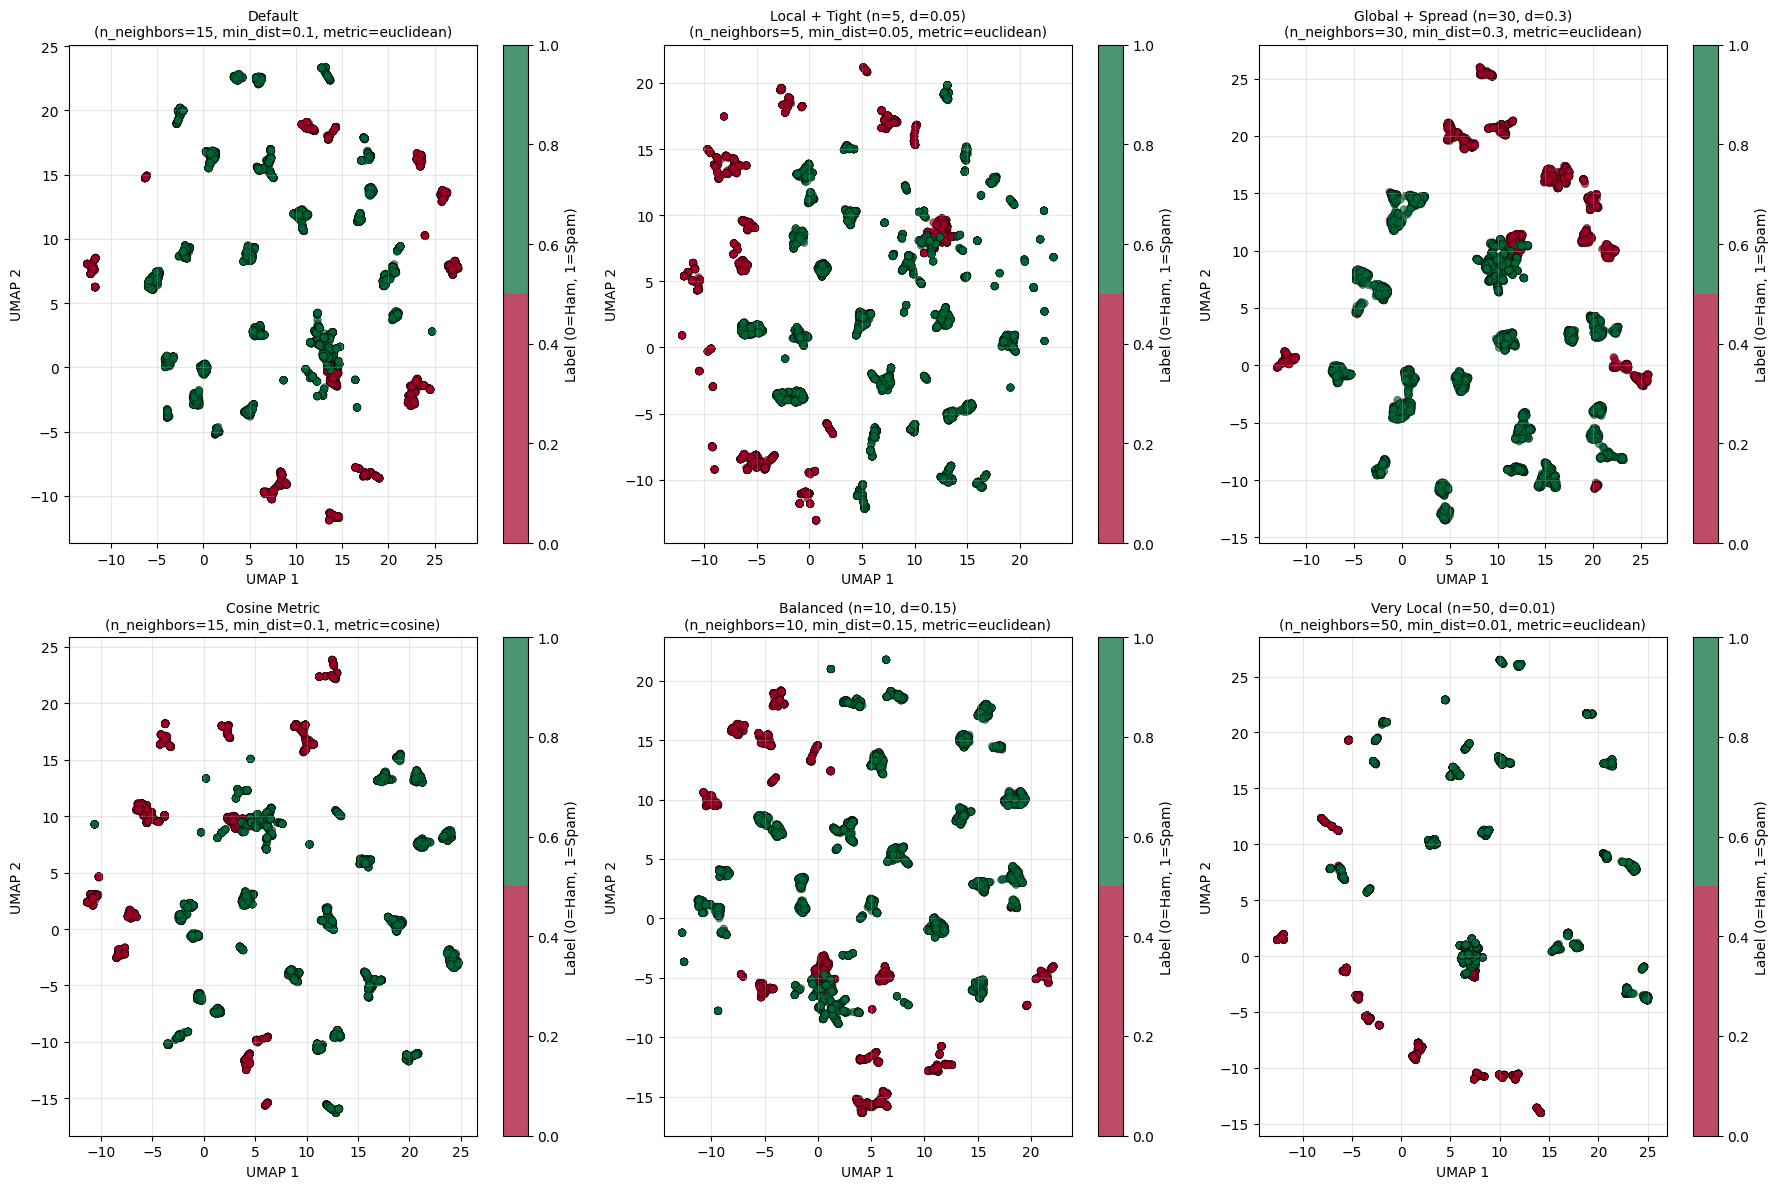


Análise comparativa concluída!
Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).


In [83]:
visualize_umap_comparisons('voyage')

Processando: Default...
Processando: Local + Tight (n=5, d=0.05)...
Processando: Global + Spread (n=30, d=0.3)...
Processando: Cosine Metric...
Processando: Balanced (n=10, d=0.15)...
Processando: Very Local (n=50, d=0.01)...


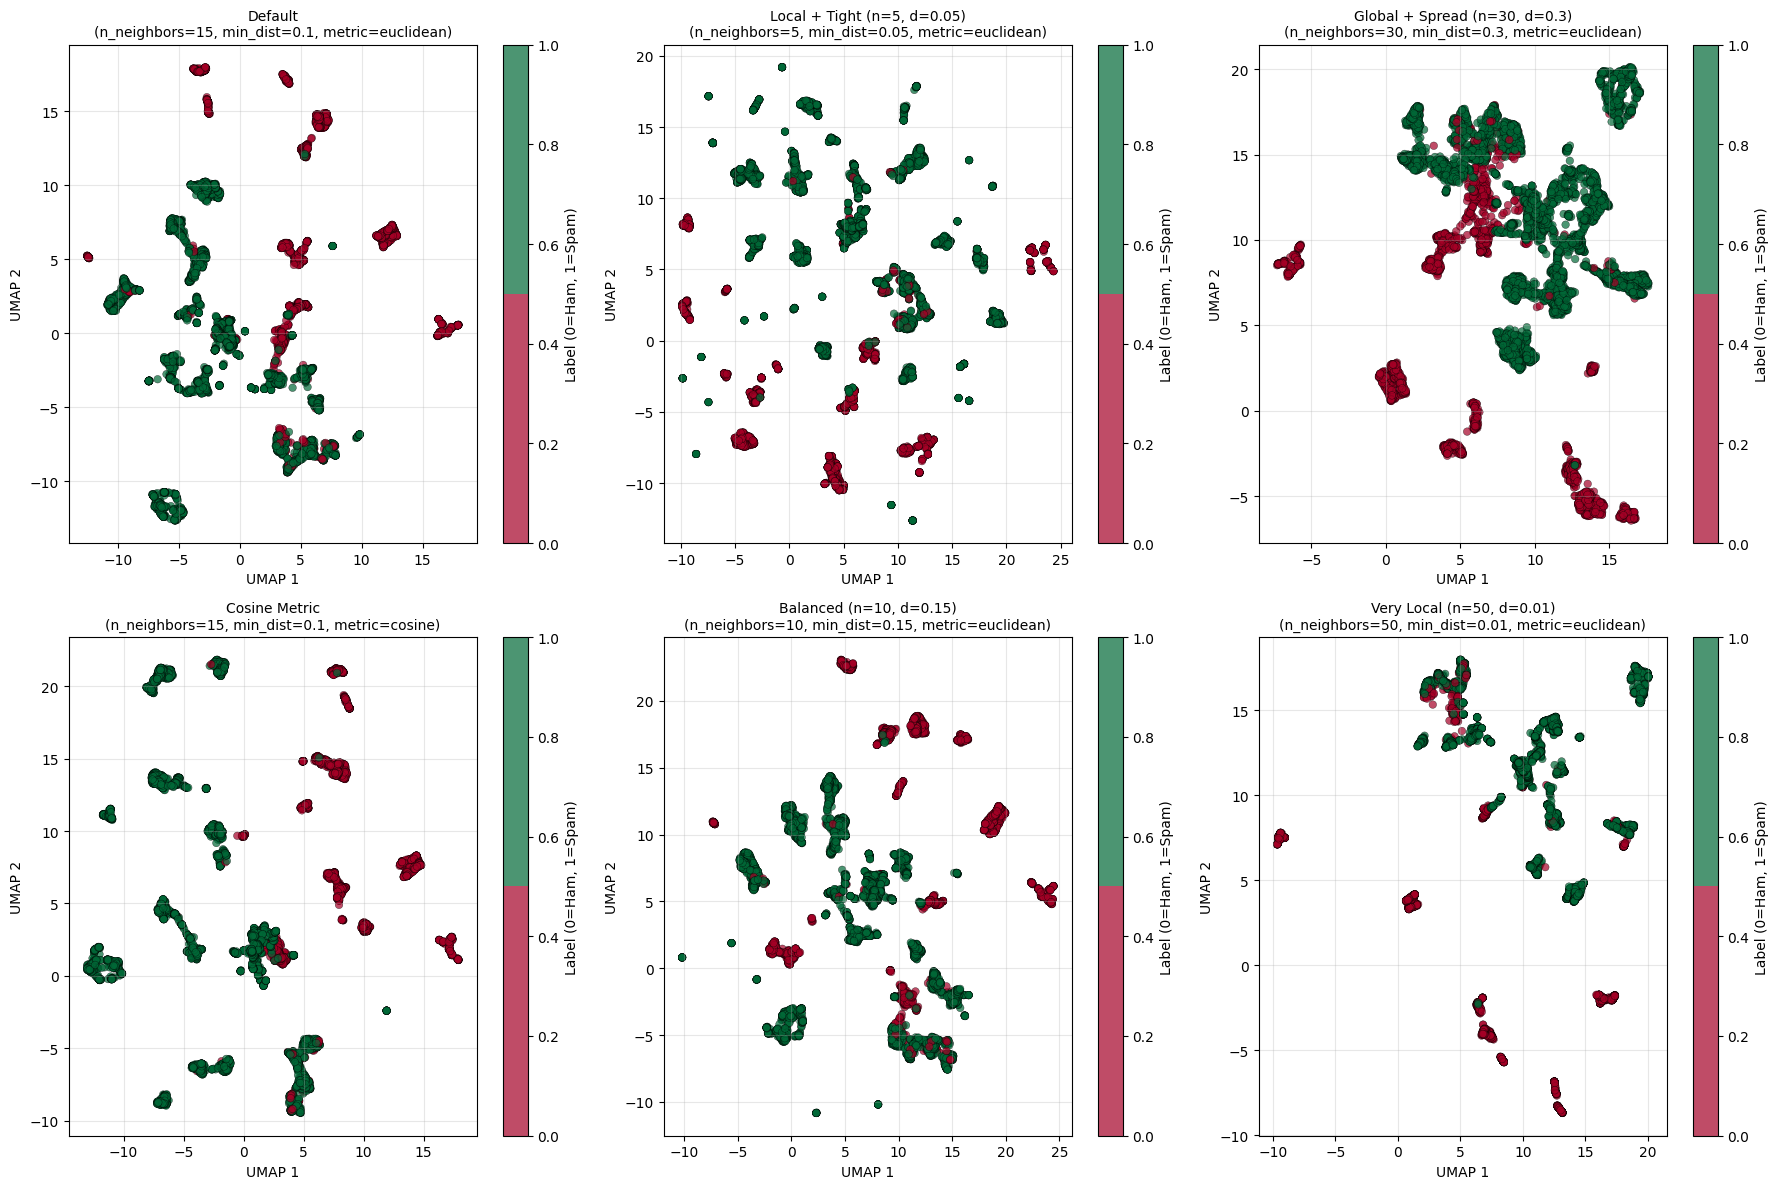


Análise comparativa concluída!
Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).


In [84]:
visualize_umap_comparisons('minilm')

Processando: Default...
Processando: Local + Tight (n=5, d=0.05)...
Processando: Global + Spread (n=30, d=0.3)...
Processando: Cosine Metric...
Processando: Balanced (n=10, d=0.15)...
Processando: Very Local (n=50, d=0.01)...


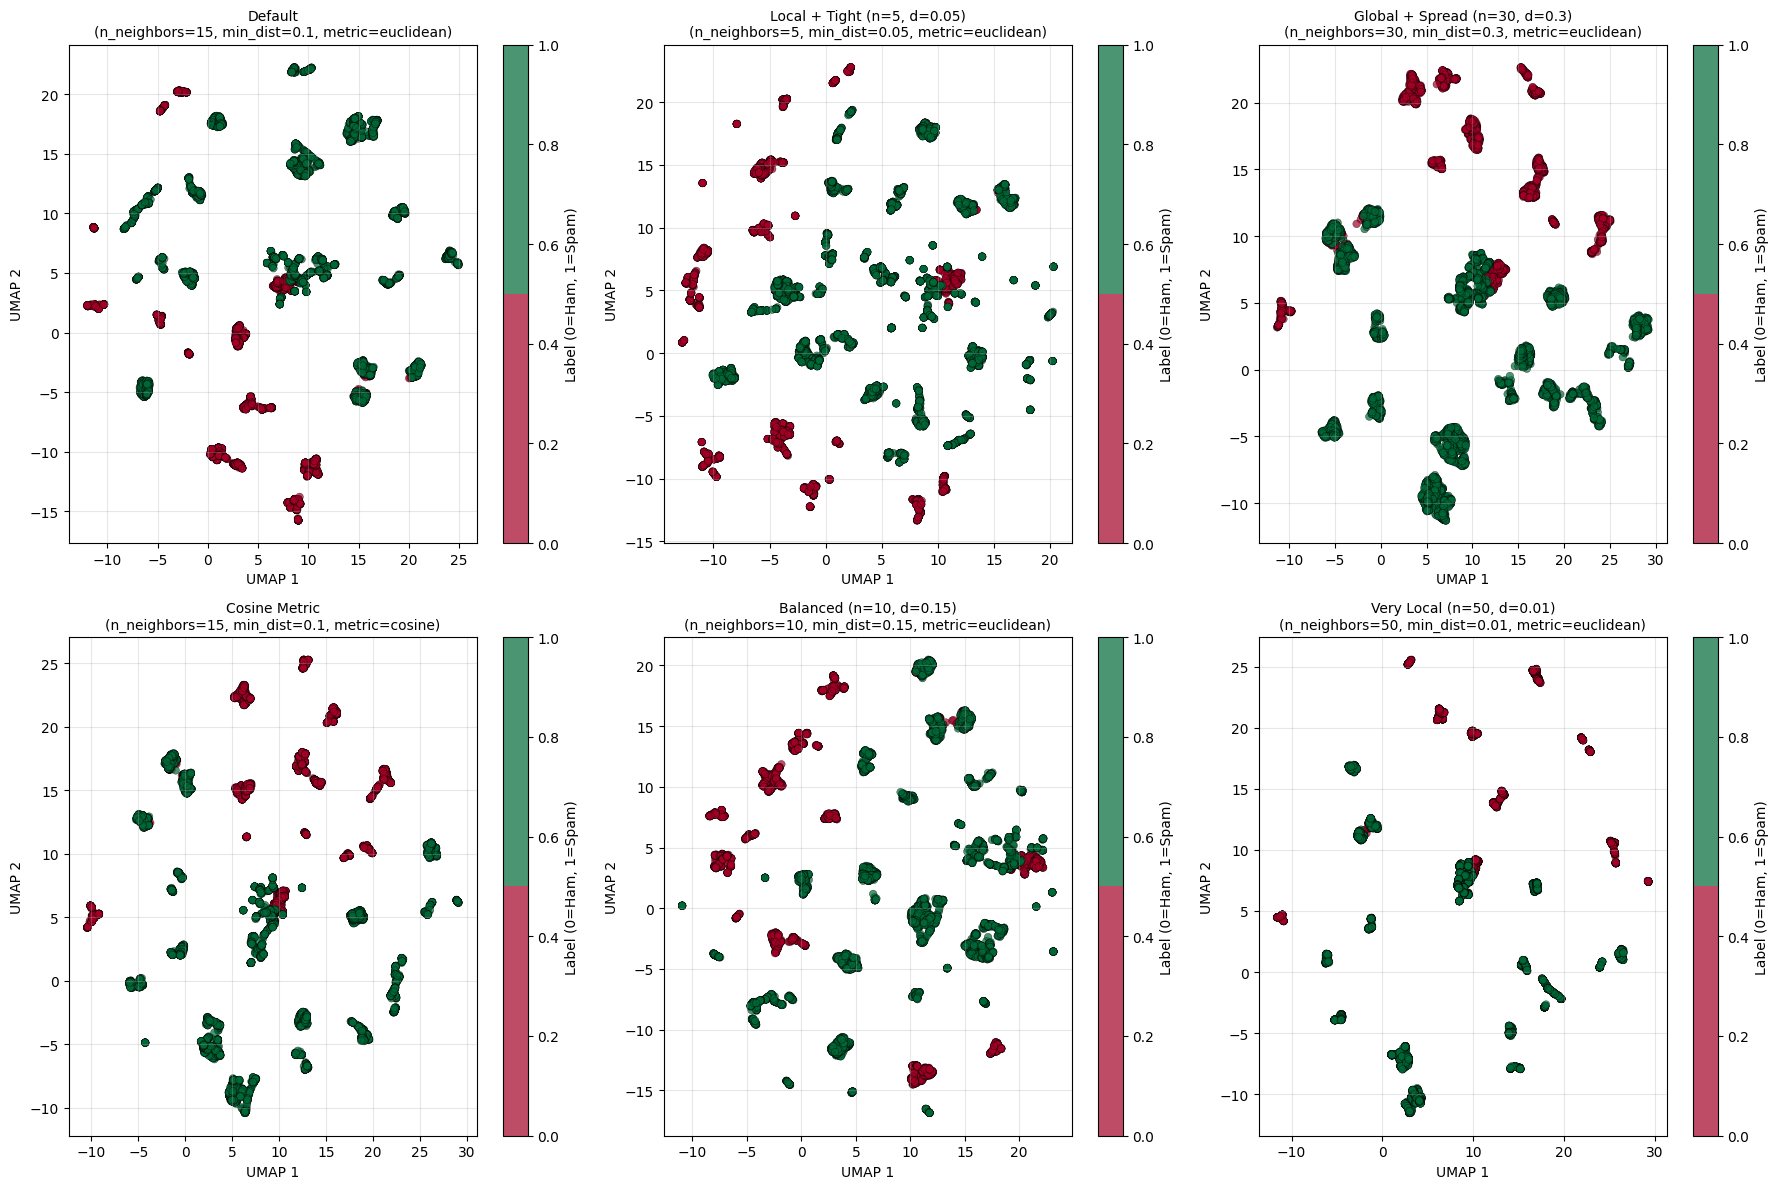


Análise comparativa concluída!
Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).


In [85]:
visualize_umap_comparisons('openai')

Processando: Default...
Processando: Local + Tight (n=5, d=0.05)...
Processando: Global + Spread (n=30, d=0.3)...
Processando: Cosine Metric...
Processando: Balanced (n=10, d=0.15)...
Processando: Very Local (n=50, d=0.01)...


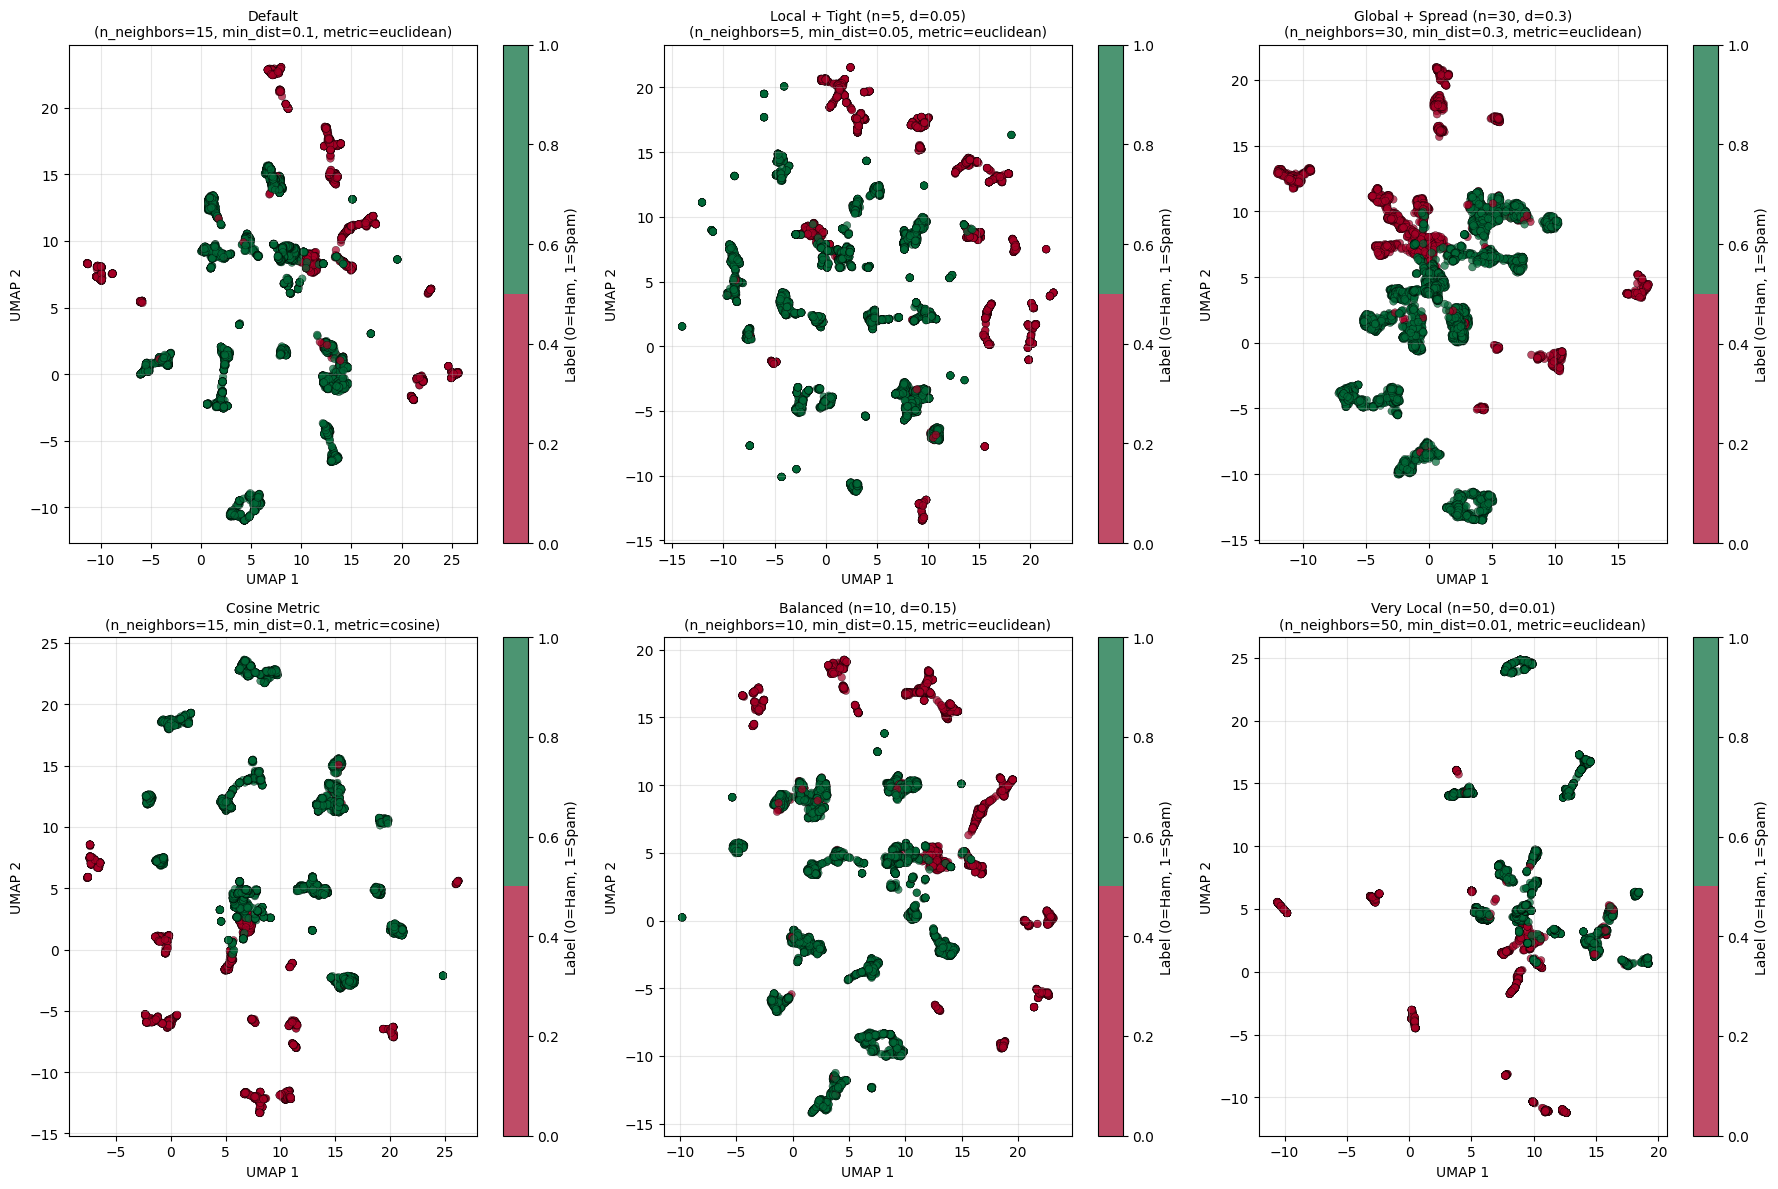


Análise comparativa concluída!
Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).


In [86]:
visualize_umap_comparisons('bge')

Processando: Default...
Processando: Local + Tight (n=5, d=0.05)...
Processando: Global + Spread (n=30, d=0.3)...
Processando: Cosine Metric...
Processando: Balanced (n=10, d=0.15)...
Processando: Very Local (n=50, d=0.01)...


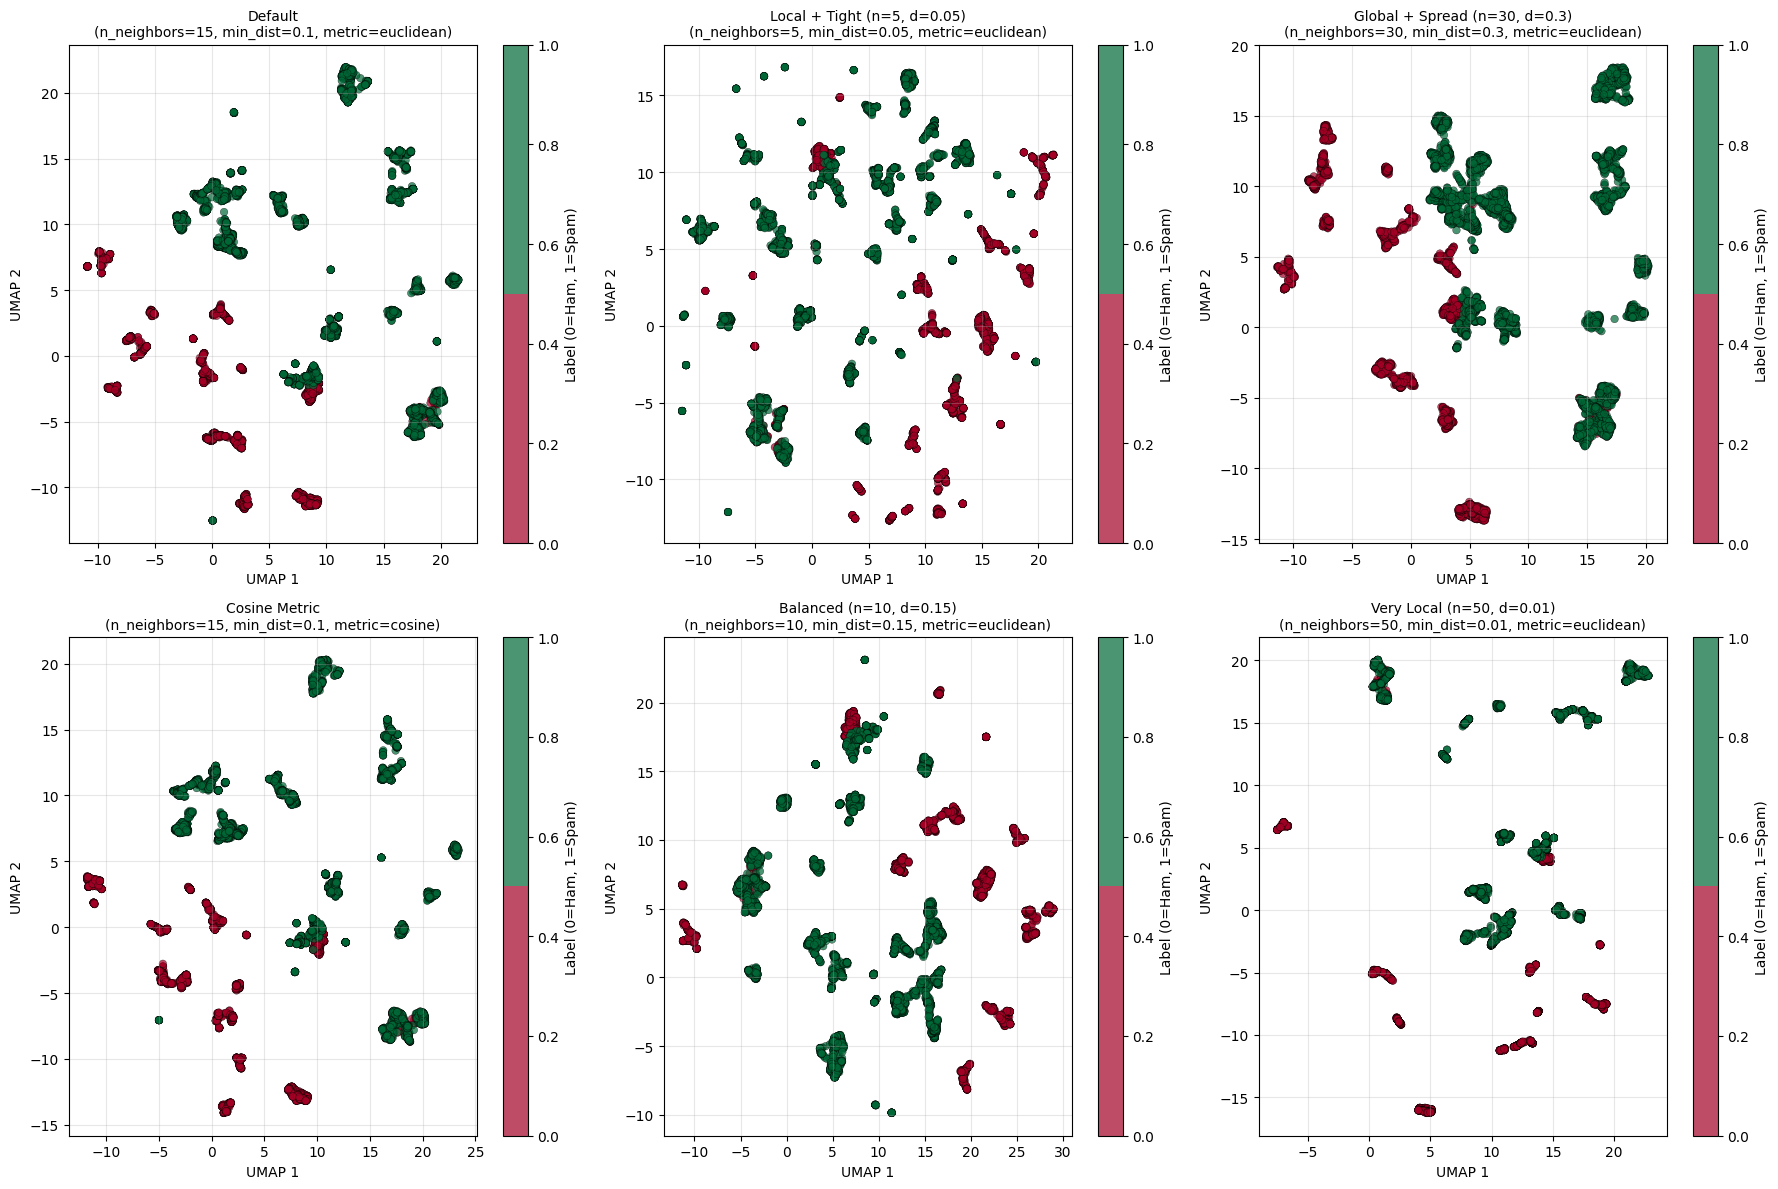


Análise comparativa concluída!
Recomendação: Escolha a configuração que melhor separa os clusters de spam (1) dos ham (0).


In [87]:
visualize_umap_comparisons('e5')

# Estudo de Dimensionalidade com UMAP para Detecção de Anomalias

Este estudo foi realizado para determinar o número ideal de dimensões (`n_components`) para a redução de dimensionalidade dos nossos embeddings de texto utilizando o **UMAP** (*Uniform Manifold Approximation and Projection*). 

O objetivo principal é comprimir o espaço vetorial original (alta dimensionalidade) para um espaço latente menor, eliminando redundâncias e ruídos matemáticos, antes de alimentar os nossos modelos de detecção de fraudes/scams (**Isolation Forest** e **One-Class SVM**).

---

## 1. O que foi feito e analisado?

Avaliamos o comportamento geométrico dos dados à medida que expandimos o espaço reduzido do UMAP de **2 até 60 dimensões**. Em vez de confiar em uma avaliação puramente visual (que nos limita a 2D ou 3D), calculamos três métricas estatísticas complementares para mapear a qualidade da compressão em cada etapa.

---

## 2. O que significam as métricas calculadas?

Para parametrizar matematicamente a fidelidade da compressão, analisamos as três curvas a seguir:

### 📊 Evolução da Separabilidade (Silhouette Score)
* **O que mede:** Mede o quão compactas são as nuvens de pontos de cada classe e o quão distantes essas nuvens estão umas das outras. O score varia de -1 a 1.
* **Comportamento observado:** Apresentou um valor alto em 2D/3D e caiu progressivamente até estabilizar a partir de 15 dimensões.
* **Por que isso acontece?** Em 2D, o UMAP é forçado a esmagar os dados em um plano, criando "bolhas" artificialmente muito densas para acomodar os vizinhos (o que infla o score). Ao darmos mais dimensões (10, 15, 25), os dados ganham liberdade para "respirar" e se espalhar realisticamente, suavizando as fronteiras geométricas.

### 📈 Evolução da Estrutura Global (Correlação de Distância %)
* **O que mede:** Avalia a macroestrutura dos dados. Ela calcula a distância entre *todos* os pontos no espaço original de alta dimensão e compara (via correlação) com as distâncias no espaço reduzido. Queremos que pontos que estavam muito distantes na realidade continuem distantes após o UMAP.
* **Comportamento observado:** Apresentou uma subida expressiva, atingindo o seu **pico absoluto em 15 dimensões (~64.5%)**, seguido de um leve declínio e estabilização.

### 📉 Evolução da Estrutura Local (Trustworthiness %)
* **O que mede:** Avalia a microestrutura (confiabilidade da vizinhança). Mede se os vizinhos mais próximos de uma mensagem no espaço original continuam sendo os seus vizinhos mais próximos no espaço reduzido.
* **Comportamento observado:** Mostrou uma arrancada rápida saindo de 2D e entrou em um **platô de estabilização perfeito a partir de 10 a 15 dimensões**, mantendo uma fidelidade excelente acima de **98.7%**.

---

## 3. Interpretação e Conclusão (O "Número Mágico")

Com base no equilíbrio das três curvas, o número ideal escolhido para fixar o hiperparâmetro `n_components` do UMAP é **15 dimensões** (aceitável também **10 dimensões** caso seja necessário otimizar o tempo de computação).

### Justificativa Técnica:
1. **Ponto de Equilíbrio Global:** Em 15 dimensões, atingimos o **pico de preservação da macroestrutura global (64.5%)**, garantindo que o panorama geral do comportamento das mensagens não foi distorcido.
2. **Estabilização Local:** É o ponto exato onde a curva de *Trustworthiness* entra em platô. Adicionar mais dimensões além disso (como 40 ou 60) traz ganho zero de fidelidade de vizinhança, servindo apenas para deixar o processamento mais lento.
3. **Distribuição Realista para a Isolation Forest:** Embora o *Silhouette Score* seja menor em 15D do que em 2D, isso indica que os dados perderam o agrupamento artificial induzido pelo esmagamento bidimensional. Para algoritmos baseados em árvores isoladoras, ter 15 eixos independentes para realizar cortes aleatórios oferece um poder de discriminação muito superior para capturar scams sutis que seriam camuflados em apenas 2D.

---
**Próximo Passo:** Fixar `n_components=15` no pipeline do UMAP e iniciar os experimentos isolados de tunagem de hiperparâmetros para os modelos `IsolationForest` e `OneClassSVM`.

In [88]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances

def calculate_umap_metrics(embedding):
    """Calcula as métricas do UMAP para um embedder específico."""
    df_test = pd.read_parquet(os.path.join(DATA_DIR, f'{embedding}_chunks.parquet'))
    X = np.array(df_test['text_embedded'].tolist(), dtype=np.float32)
    y = np.array(df_test['label'].tolist())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    dist_alta = pairwise_distances(X_scaled, metric='cosine').flatten()
    dimensoes = [2, 3, 5, 10, 15, 25, 40, 60]

    lista_silhouette = []
    lista_correlation = []
    lista_trust = []

    print(f"\n Calculando métricas para o embedder: {embedding}")
    for dim in dimensoes:
        reducer = umap.UMAP(n_components=dim, metric='cosine', n_neighbors=15, random_state=42, n_jobs=-1)
        X_umap = reducer.fit_transform(X_scaled)
        
        sil = silhouette_score(X_umap, y)
        lista_silhouette.append(sil)
        
        dist_baixa = pairwise_distances(X_umap, metric='euclidean').flatten()
        corr = np.corrcoef(dist_alta, dist_baixa)[0, 1]
        lista_correlation.append(corr * 100)
        
        trust = trustworthiness(X_scaled, X_umap, n_neighbors=15)
        lista_trust.append(trust * 100)
        
        print(f"   -> Concluído para {dim:2d} dimensões.")

    return dimensoes, lista_silhouette, lista_correlation, lista_trust


def compare_multiple_embedders(emb_list):
    """Gera os gráficos sobrepostos para a lista de embedders fornecida."""
    # Criamos os subplots antes do loop para acumular as linhas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Paleta de cores para diferenciar os embedders (estilo científico/moderno)
    cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, emb in enumerate(emb_list):
        # Evita estouro de índice de cores caso tenha muitos embedders
        cor = cores[idx % len(cores)] 
        
        # Calcula os dados de evolução
        dimensoes, sil, corr, trust = calculate_umap_metrics(emb)
        
        # Gráfico 1: Silhouette Score (Linhas sobrepostas)
        axes[0].plot(dimensoes, sil, marker='o', linewidth=2, color=cor, label=emb)
        
        # Gráfico 2: Global Distance Correlation (Linhas sobrepostas)
        axes[1].plot(dimensoes, corr, marker='s', linewidth=2, color=cor, label=emb)
        
        # Gráfico 3: Trustworthiness (Linhas sobrepostas)
        axes[2].plot(dimensoes, trust, marker='^', linewidth=2, color=cor, label=emb)

    # --- CONFIGURAÇÃO E FORMATAÇÃO DOS GRÁFICOS ---
    print("\nRenderizando gráficos comparativos sobrepostos...")
    
    # Títulos e labels das colunas
    axes[0].set_title('Evolução da Separabilidade\n(Silhouette Score)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Score (Maior = Classes Mais Isoladas)')
    
    axes[1].set_title('Evolução da Estrutura Global\n(Correlação de Distância %)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Fidelidade Global (%)')
    
    axes[2].set_title('Evolução da Estrutura Local\n(Trustworthiness %)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Fidelidade Local (%)')

    # Ajustes universais para os 3 eixos
    for ax in axes:
        ax.set_xlabel('Dimensões Reduzidas (n_components)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best') # Mostra a legenda identificando qual cor é qual embedder
        ax.set_xticks(dimensoes) # Garante que os números das dimensões apareçam no eixo X

    plt.suptitle('Comparativo de Dimensionalidade UMAP entre Embedders', fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


 Calculando métricas para o embedder: minilm
   -> Concluído para  2 dimensões.
   -> Concluído para  3 dimensões.
   -> Concluído para  5 dimensões.
   -> Concluído para 10 dimensões.
   -> Concluído para 15 dimensões.
   -> Concluído para 25 dimensões.
   -> Concluído para 40 dimensões.
   -> Concluído para 60 dimensões.

 Calculando métricas para o embedder: voyage
   -> Concluído para  2 dimensões.
   -> Concluído para  3 dimensões.
   -> Concluído para  5 dimensões.
   -> Concluído para 10 dimensões.
   -> Concluído para 15 dimensões.
   -> Concluído para 25 dimensões.
   -> Concluído para 40 dimensões.
   -> Concluído para 60 dimensões.

 Calculando métricas para o embedder: openai
   -> Concluído para  2 dimensões.
   -> Concluído para  3 dimensões.
   -> Concluído para  5 dimensões.
   -> Concluído para 10 dimensões.
   -> Concluído para 15 dimensões.
   -> Concluído para 25 dimensões.
   -> Concluído para 40 dimensões.
   -> Concluído para 60 dimensões.

 Calculando métricas 

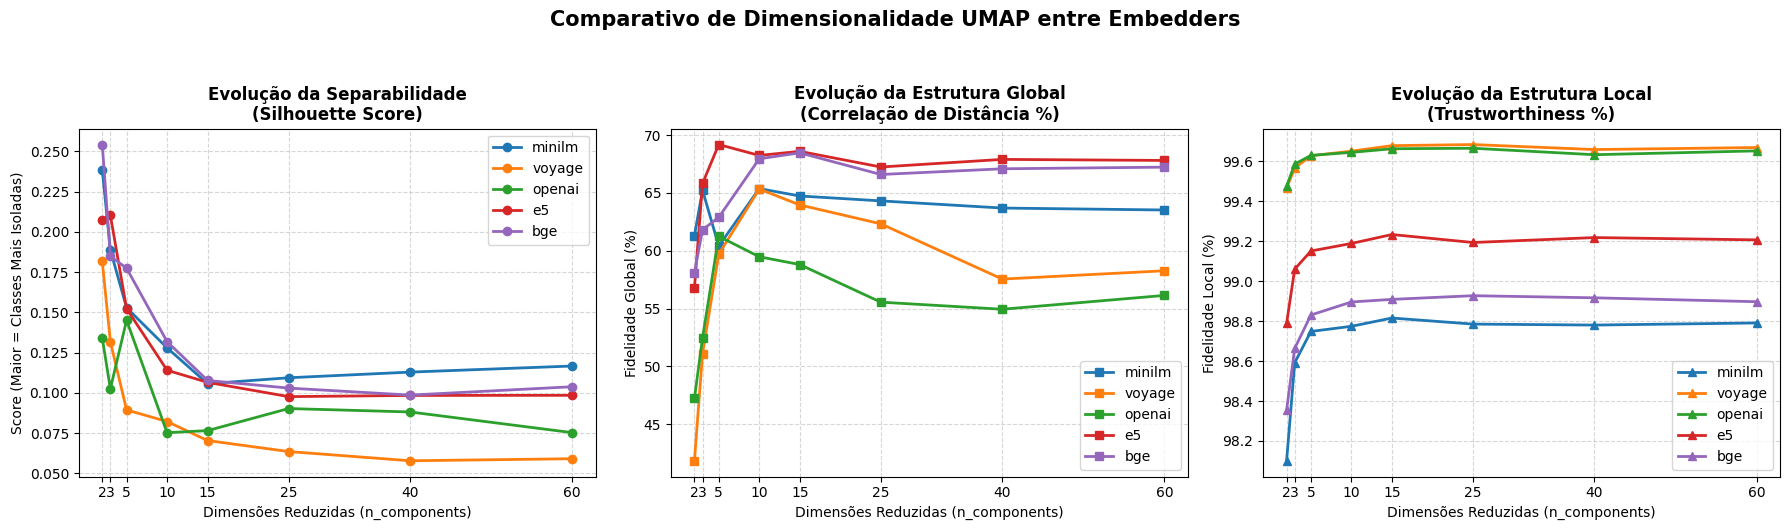

In [89]:

compare_multiple_embedders(EMBEDDERS.keys())

## Testando Diferentes Parâmetros do PCA

O PCA é uma estratégia linear de para redução de dimensionalidade, permitindo que possamos visualizar como nossos dados se dividem e se comportam a partir dos dois componentes mais significativos. Nesse sentido, podemos ainda explorar parâmetros para aumentar essa divisão de labels


In [90]:
# --- ESTUDOS SOBRE PCA ----
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import math

# Função para aplicar PCA e visualizar resultados para vários embedders
def visualize_pca_for_embedders(emb_list=None, n_components=2, whiten=False, scale=True):
    if emb_list is None:
        emb_list = list(EMBEDDERS.keys())

    n = len(emb_list)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.ravel() if n > 1 else [axes]

    for idx, emb in enumerate(emb_list):
        df = pd.read_parquet(os.path.join(DATA_DIR, f'{emb}_chunks.parquet'))
        X = np.array(df['text_embedded'].tolist(), dtype=np.float32)
        y = np.array(df['label'].tolist())

        # Optionally scale before PCA (recommended for PCA)
        if scale:
            scaler = StandardScaler()
            X_proc = scaler.fit_transform(X)
        else:
            X_proc = X

        pca = PCA(n_components=n_components, whiten=whiten, random_state=42)
        X_pca = pca.fit_transform(X_proc)

        var_ratios = pca.explained_variance_ratio_
        explained = var_ratios.sum() * 100 if len(var_ratios) > 0 else 0

        ax = axes[idx]
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=20, alpha=0.7)
        ax.set_title(f'{emb} — PCA (explained={explained:.1f}% )')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)
        # show explained variance for each component in subtitle
        comp_info = ', '.join([f'{r*100:.1f}%' for r in var_ratios])
        ax.text(0.99, 0.01, comp_info, transform=ax.transAxes, ha='right', va='bottom', fontsize=8, bbox=dict(alpha=0.0))
        plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)

    # Remove unused subplots
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


**Discussão — Parâmetros do PCA e opções a considerar**

- **n_components**: número de componentes principais a calcular. Para visualização, usamos 2, mas aumentar para 3 pode ajudar a explorar estruturas tridimensionais (usar `mpl_toolkits.mplot3d` para plot).
- **whiten**: se `True`, os componentes são escalados para terem variância unitária. Pode melhorar desempenho de alguns algoritmos posteriores, mas altera as relações de distância; para visualização geralmente `False` é preferível.
- **scale (StandardScaler)**: o PCA é sensível à escala das features. Para embeddings densos, o scale normalmente ajuda, garantindo que todas as dimensões contribuam de forma equilibrada. Em alguns casos (embeddings já normalizados) pode ser desnecessário.
- **svd_solver**: definível em `PCA(svd_solver=...)` — `auto`, `full`, `arpack`, `randomized`. Para grandes datasets, `randomized` é mais rápido e suficiente para poucas componentes.
- **alternativas**: se os dados são esparsos ou muito grandes, `TruncatedSVD` pode ser mais indicado; para relações não-lineares, mantenha UMAP/t-SNE; para maior interpretabilidade, experimente rotacionar componentes (varimax) ou usar `KernelPCA` para projeções não-lineares.

Recomendações práticas:
- Sempre verificar `explained_variance_ratio_` para entender quanto da variância é capturada pelas componentes (se baixo, a projeção linear pode não separar classes).
- Testar `whiten=True` e `scale=True` apenas se for necessário para modelos downstream; para visualização prefira manter `whiten=False` inicialmente.
- Para grandes amostras, use `svd_solver='randomized'` para acelerar a decomposição.

Métricas calculadas na função:
- var_ratios: retorna uma lista (array) onde cada número representa a porcentagem da variância total original que aquele componente específico conseguiu captura. Exemplo: Se a lista retornar [0.35, 0.15], isso significa que o Eixo X (PC1) sozinho carrega 35% de toda a informação original dos seus textos, e o Eixo Y (PC2) carrega 15%
- explained: é a Variância Explicada Acumulada (Cumulative Explained Variance). O código simplesmente soma as porcentagens individuais da lista acima e multiplica por 100 para transformar em um número legível
- comp_info: Em vez de deixar os números puros do Python, ela formata para algo como: "35.0%, 15.0%". Isso permite que, ao bater o olho no gráfico, você saiba exatamente o peso do eixo X e do eixo Y.


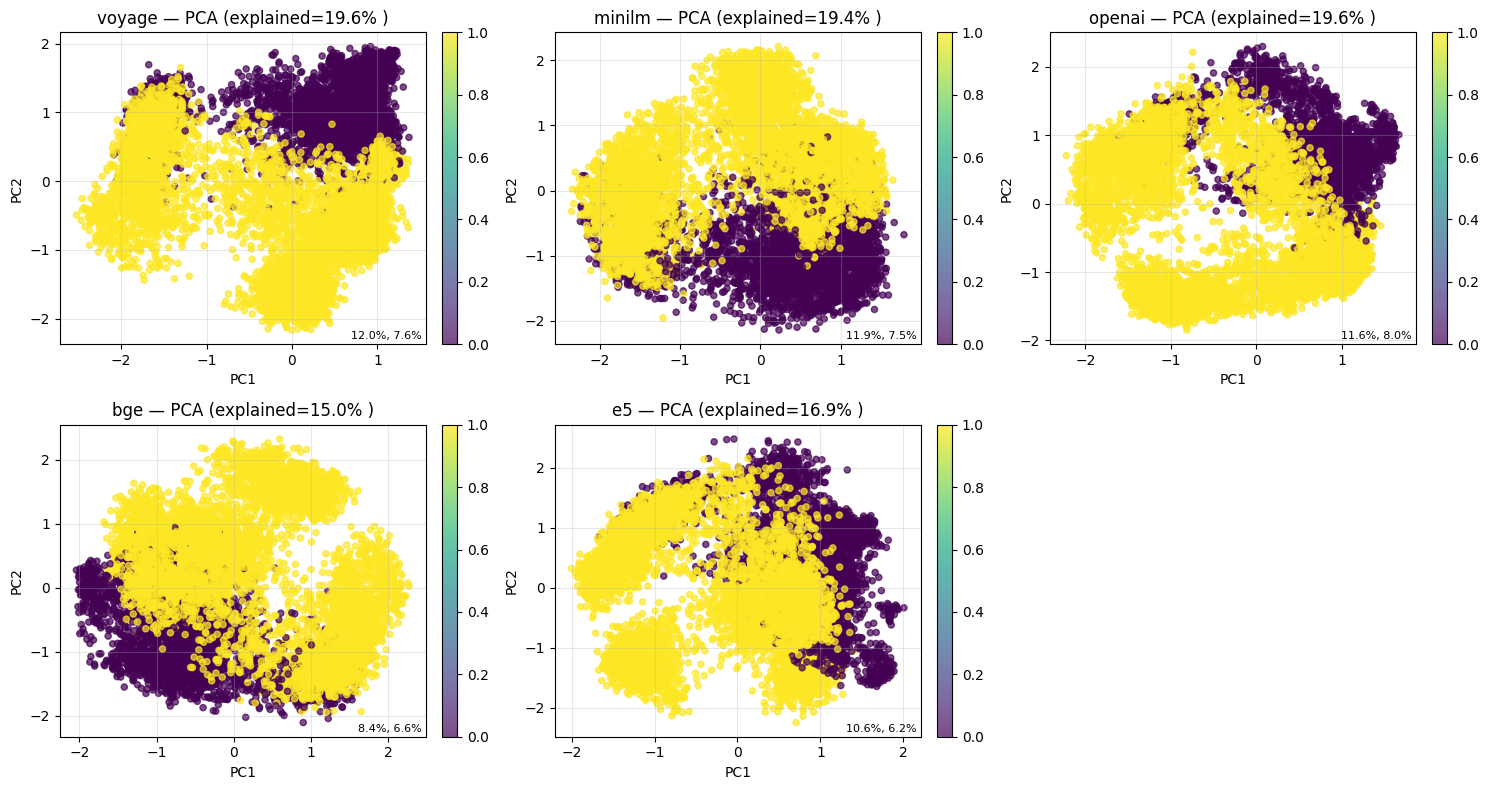

In [91]:
visualize_pca_for_embedders(['voyage','minilm', 'openai', 'bge', 'e5'], n_components=2, whiten=True, scale=True)

In [ ]:
def calculate_pca_metrics(embedding):
    """Calcula as métricas do PCA para um embedder específico usando dimensões fixas."""
    df_test = pd.read_parquet(os.path.join(DATA_DIR, f'{embedding}_chunks.parquet'))
    X = np.array(df_test['text_embedded'].tolist(), dtype=np.float32)
    y = np.array(df_test['label'].tolist())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Distâncias originais (Cosseno) para a métrica global
    dist_alta = pairwise_distances(X_scaled, metric='cosine').flatten()
    
    # Mesma lista de dimensões do UMAP para o gráfico bater certinho
    dimensoes = [2, 3, 5, 10, 15, 25, 40, 60]

    lista_silhouette = []
    lista_correlation = []
    lista_trust = []

    print(f"\nCalculando métricas de PCA para o embedder: {embedding}")
    for dim in dimensoes:
        # Forçamos o PCA a reduzir para o número exato de dimensões da iteração
        reducer = PCA(n_components=dim, random_state=42)
        X_pca = reducer.fit_transform(X_scaled)
        
        # 1. Métrica de Separabilidade (Silhouette)
        sil = silhouette_score(X_pca, y)
        lista_silhouette.append(sil)
        
        # 2. Métrica de Macroestrutura (Correlação de Distância Global)
        dist_baixa = pairwise_distances(X_pca, metric='euclidean').flatten()
        corr = np.corrcoef(dist_alta, dist_baixa)[0, 1]
        lista_correlation.append(corr * 100)
        
        # 3. Métrica de Microestrutura (Trustworthiness)
        trust = trustworthiness(X_scaled, X_pca, n_neighbors=15)
        lista_trust.append(trust * 100)
        
        print(f"   -> Concluído para {dim:2d} dimensões no PCA.")

    return dimensoes, lista_silhouette, lista_correlation, lista_trust

def compare_pca_multiple_embedders(emb_list):
    """Gera os gráficos sobrepostos para a lista de embedders fornecida."""
    # Criamos os subplots antes do loop para acumular as linhas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Paleta de cores para diferenciar os embedders (estilo científico/moderno)
    cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, emb in enumerate(emb_list):
        # Evita estouro de índice de cores caso tenha muitos embedders
        cor = cores[idx % len(cores)] 
        
        # Calcula os dados de evolução
        dimensoes, sil, corr, trust = calculate_pca_metrics(emb)
        
        # Gráfico 1: Silhouette Score (Linhas sobrepostas)
        axes[0].plot(dimensoes, sil, marker='o', linewidth=2, color=cor, label=emb)
        
        # Gráfico 2: Global Distance Correlation (Linhas sobrepostas)
        axes[1].plot(dimensoes, corr, marker='s', linewidth=2, color=cor, label=emb)
        
        # Gráfico 3: Trustworthiness (Linhas sobrepostas)
        axes[2].plot(dimensoes, trust, marker='^', linewidth=2, color=cor, label=emb)

    # --- CONFIGURAÇÃO E FORMATAÇÃO DOS GRÁFICOS ---
    print("\nRenderizando gráficos comparativos sobrepostos...")
    
    # Títulos e labels das colunas
    axes[0].set_title('Evolução da Separabilidade\n(Silhouette Score)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Score (Maior = Classes Mais Isoladas)')
    
    axes[1].set_title('Evolução da Estrutura Global\n(Correlação de Distância %)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Fidelidade Global (%)')
    
    axes[2].set_title('Evolução da Estrutura Local\n(Trustworthiness %)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Fidelidade Local (%)')

    # Ajustes universais para os 3 eixos
    for ax in axes:
        ax.set_xlabel('Dimensões Reduzidas (n_components)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best') # Mostra a legenda identificando qual cor é qual embedder
        ax.set_xticks(dimensoes) # Garante que os números das dimensões apareçam no eixo X

    plt.suptitle('Comparativo de Dimensionalidade PCA entre Embedders', fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


Calculando métricas de PCA para o embedder: minilm
   -> Concluído para  2 dimensões no PCA.
   -> Concluído para  3 dimensões no PCA.
   -> Concluído para  5 dimensões no PCA.
   -> Concluído para 10 dimensões no PCA.
   -> Concluído para 15 dimensões no PCA.
   -> Concluído para 25 dimensões no PCA.
   -> Concluído para 40 dimensões no PCA.
   -> Concluído para 60 dimensões no PCA.

Calculando métricas de PCA para o embedder: voyage
   -> Concluído para  2 dimensões no PCA.
   -> Concluído para  3 dimensões no PCA.
   -> Concluído para  5 dimensões no PCA.
   -> Concluído para 10 dimensões no PCA.
   -> Concluído para 15 dimensões no PCA.
   -> Concluído para 25 dimensões no PCA.
   -> Concluído para 40 dimensões no PCA.
   -> Concluído para 60 dimensões no PCA.

Calculando métricas de PCA para o embedder: openai
   -> Concluído para  2 dimensões no PCA.
   -> Concluído para  3 dimensões no PCA.
   -> Concluído para  5 dimensões no PCA.
   -> Concluído para 10 dimensões no PCA.
   -

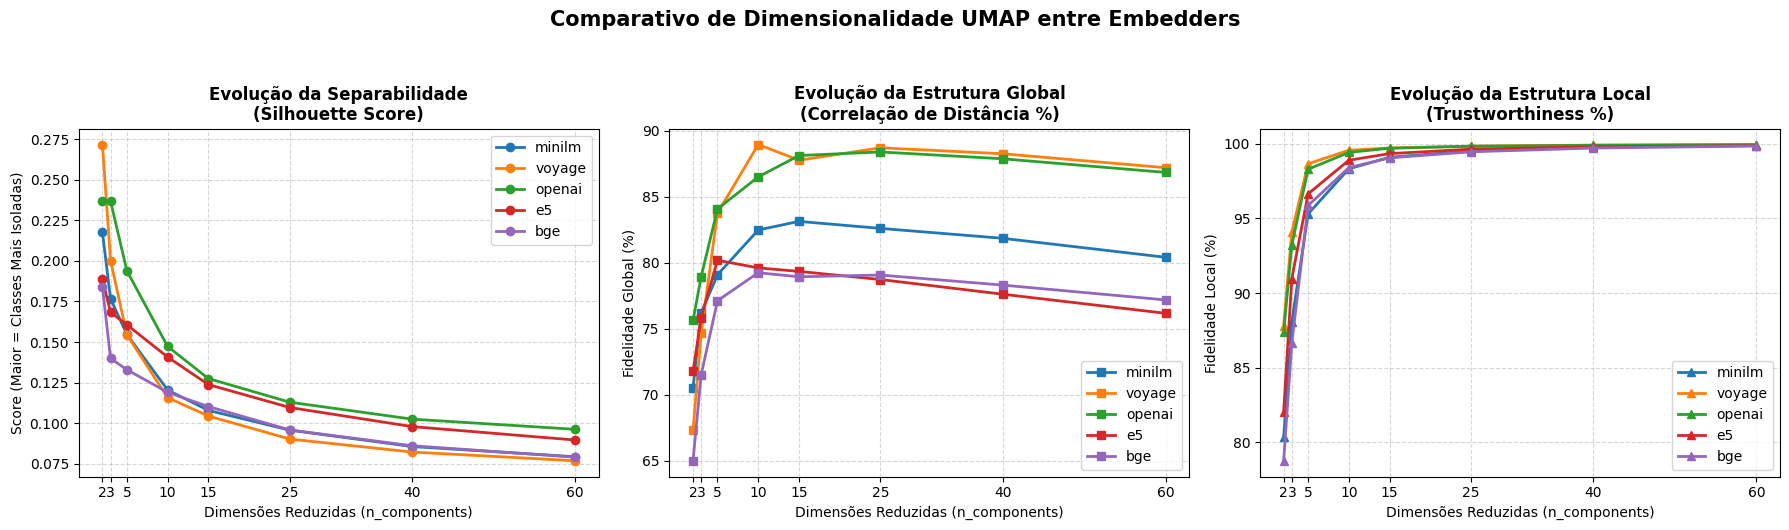

In [93]:
compare_pca_multiple_embedders(EMBEDDERS.keys())

**Descobrindo o unmero de componentes ideal**

Como nossos embeddings tem até 1000 dimensões, claro que não conseguiremos um bom resultado em 2D. Por isso, vamos explorar como nossa representação melhora com o aumento de componentes


In [94]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def calculate_pca_variance_for_dimensions(embedder, dimensoes):
    """
    Carrega o dataset de um embedder e calcula a variância explicada 
    acumulada para uma lista específica de dimensões.
    """
    # Carrega os dados
    df_test = pd.read_parquet(os.path.join(DATA_DIR, f'{embedder}_chunks.parquet'))
    X = np.array(df_test['text_embedded'].tolist(), dtype=np.float32)
    
    # Padronização (Crucial para o PCA funcionar corretamente)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    variancias_acumuladas = []
    
    print(f"Analisando retenção de variância no PCA para: {embedder}")
    
    # Para evitar erros, garantimos que não tentamos extrair mais componentes 
    # do que o número máximo de features originais do embedding
    max_features_possiveis = X_scaled.shape[1]
    
    for dim in dimensoes:
        if dim > max_features_possiveis:
            print(f"   -> Dimensão {dim} ignorada (excede o tamanho original de {max_features_possiveis}D).")
            continue
            
        # Ajusta o PCA para o número fixo de componentes atual
        pca = PCA(n_components=dim, random_state=42)
        pca.fit(X_scaled)
        
        # Soma a variância de todos os componentes calculados nesta rodada
        actual_variance = np.sum(pca.explained_variance_ratio_) * 100
        variancias_acumuladas.append(actual_variance)
        
        print(f"   -> Componentes: {dim:2d} | Variância Retida: {actual_variance:.2f}%")
        
    return variancias_acumuladas

def compare_pca_variance_across_embedders(emb_list, dimensoes=[2, 3, 5, 10, 15, 25, 40, 60]):
    """
    Roda a análise para múltiplos embedders e gera um único gráfico 
    comparando a evolução da variância retida de todos eles.
    """
    plt.figure(figsize=(12, 7))
    
    # Paleta de cores padrão estável para os modelos
    cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, emb in enumerate(emb_list):
        cor = cores[idx % len(cores)]
        
        # Calcula as variâncias para as dimensões fornecidas
        variancias = calculate_pca_variance_for_dimensions(emb, dimensoes)
        
        # Ajusta o tamanho da lista de dimensões caso alguma tenha sido pulada no loop interno
        dims_plot = dimensoes[:len(variancias)]
        
        # Plota a linha do embedder atual
        plt.plot(dims_plot, variancias, marker='o', linewidth=2.5, color=cor, label=f'{emb}')
        
    # --- FORMATAÇÃO DO GRÁFICO COMPARATIVO ---
    # Linhas de referência de qualidade comuns no mercado
    plt.axhline(y=80, color='r', linestyle='--', alpha=0.4, label='Meta de 80% de Variância')
    plt.axhline(y=90, color='g', linestyle='--', alpha=0.4, label='Meta de 90% de Variância')
    
    plt.title('Comparativo de Retenção de Variância Acumulada (PCA)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Número de Componentes Principais (Dimensões Reduzidas)', fontsize=11)
    plt.ylabel('Variância Explicada Acumulada (%)', fontsize=11)
    
    # Força os ticks do eixo X a serem exatamente as dimensões testadas
    plt.xticks(dimensoes)
    plt.ylim(bottom=min(20, plt.ylim()[0]), top=105) # Garante margem para visualizar as linhas de 80/90%
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

Analisando retenção de variância no PCA para: minilm
   -> Componentes:  2 | Variância Retida: 19.45%
   -> Componentes:  3 | Variância Retida: 24.71%
   -> Componentes:  5 | Variância Retida: 33.31%
   -> Componentes: 10 | Variância Retida: 46.80%
   -> Componentes: 15 | Variância Retida: 54.15%
   -> Componentes: 25 | Variância Retida: 63.25%
   -> Componentes: 40 | Variância Retida: 71.25%
   -> Componentes: 60 | Variância Retida: 77.95%
   -> Componentes: 100 | Variância Retida: 86.24%
   -> Componentes: 150 | Variância Retida: 92.26%
   -> Componentes: 200 | Variância Retida: 95.93%
   -> Componentes: 250 | Variância Retida: 98.19%
   -> Componentes: 300 | Variância Retida: 99.39%
   -> Dimensão 400 ignorada (excede o tamanho original de 384D).
Analisando retenção de variância no PCA para: voyage
   -> Componentes:  2 | Variância Retida: 19.63%
   -> Componentes:  3 | Variância Retida: 25.83%
   -> Componentes:  5 | Variância Retida: 36.03%
   -> Componentes: 10 | Variância Retida

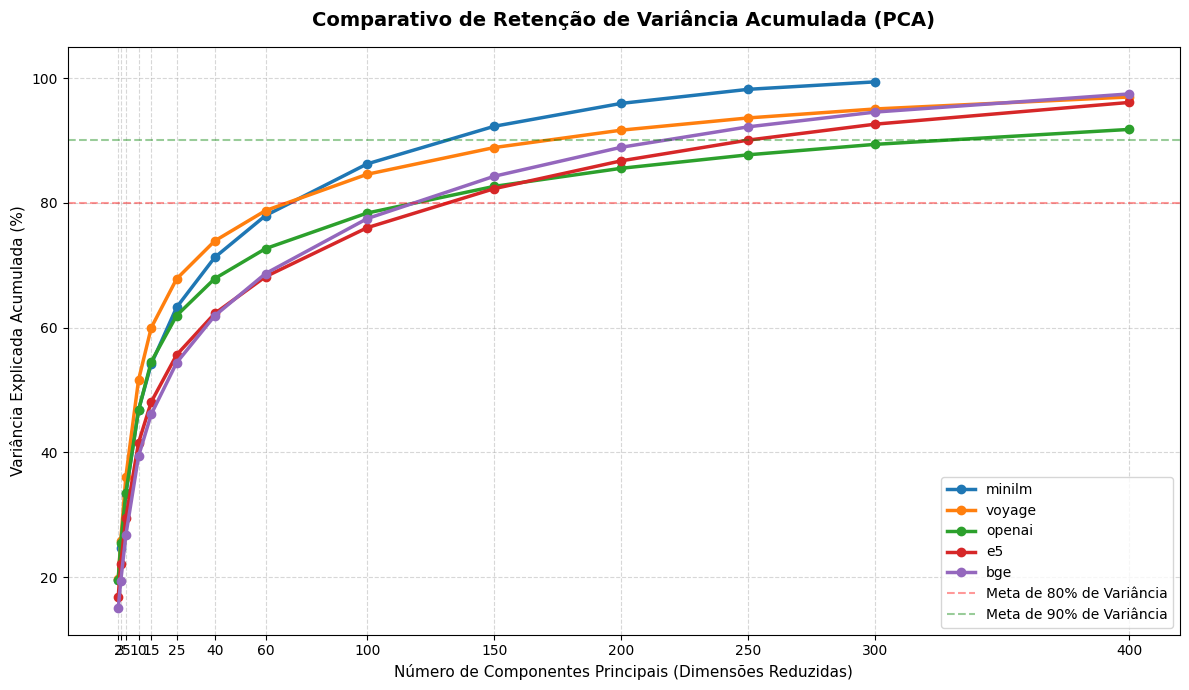

In [95]:
lista_de_modelos = ['minilm', 'voyage', 'openai', 'e5', 'bge']
dim_alvo = [2, 3, 5, 10, 15, 25, 40, 60, 100, 150, 200, 250, 300, 400]
compare_pca_variance_across_embedders(lista_de_modelos, dimensoes=dim_alvo)



# Justificativa Metodológica: Seleção do PCA vs. UMAP

Durante a fase de exploração e preparação do nosso pipeline de detecção de anomalias (*scam detection*), realizamos um estudo comparativo rigoroso entre duas técnicas proeminentes de redução de dimensionalidade: **PCA** (*Principal Component Analysis*) e **UMAP** (*Uniform Manifold Approximation and Projection*). 

O objetivo foi avaliar qual algoritmo preparava o espaço geométrico de forma mais fiel e robusta para os classificadores subsequentes (**One-Class SVM** e **Isolation Forest**). Com base nas evidências empíricas coletadas, **o PCA foi selecionado como a técnica definitiva para o projeto**.

---

## 1. Análise Empírica dos Resultados

Abaixo estão detalhados os comportamentos observados em cada uma das métricas analisadas nos experimentos anteriores:

### A. Preservação da Estrutura Global (Fidelidade Macroscópica)
* **UMAP:** Apresentou sérias limitações para mapear a macroestrutura global das distâncias semânticas, estabilizando e sofrendo um teto de vidro na faixa de **60% a 65%** de correlação de distância.
* **PCA:** Demonstrou uma superioridade matemática esmagadora, alcançando entre **85% e 90%** de fidelidade global ao atingir de 10 a 15 dimensões (especialmente utilizando os modelos de embedding `voyage` e `openai`). 
* **Impacto no Modelo:** O One-Class SVM com kernel RBF depende crucialmente do cálculo exato de distâncias absolutas no hiperespaço. A perda de 35% da estrutura global induzida pelo UMAP distorceria a fronteira de decisão, enquanto o PCA garante que a separação entre dados legítimos e fraudes permaneça geometricamente fiel à realidade.

### B. Preservação da Estrutura Local (Trustworthiness)
* **UMAP:** Embora o UMAP seja conhecido por proteger vizinhanças locais, sua curva de *Trustworthiness* nos nossos dados de texto estabilizou em um patô de **98.5% a 99%**.
* **PCA:** Surpreendeu ao escalar sua fidelidade local de forma extremamente veloz. A partir de 15 dimensões, o PCA atingiu um índice de confiança de vizinhança de **~100%**. Isso prova que, para a estrutura de densidade dos nossos embeddings de texto, a projeção linear do PCA foi capaz de manter a vizinhança intacta sem a necessidade de deformações espaciais não-lineares.

---

## 2. A Natureza dos Embeddings de Texto e o PCA

A análise da curva de variância acumulada do PCA revelou uma característica intrínseca dos modelos de linguagem modernos (`voyage`, `openai`, `bge`, `e5`, `minilm`): a informação semântica é altamente esparsa e distribuída ao longo de todo o vetor. 

Diferente de dados tabulares tradicionais, os embeddings de texto não concentram 90% de sua variância em 2 ou 3 componentes. No entanto, o comportamento previsível e linear do PCA traz três vantagens críticas que o UMAP não possui:

1. **Ausência de Distorção de Distância:** O UMAP funciona como uma "folha de borracha", esticando e encolhendo o espaço para acomodar grafos locais. Isso deforma as distâncias absolutas. O PCA apenas rotaciona e projeta os eixos de forma rígida, preservando a métrica de distância pura que a *Isolation Forest* utiliza para isolar pontos.
2. **Determinismo:** O PCA é um algoritmo puramente determinístico baseado em Álgebra Linear (SVD). O UMAP possui componentes estocásticos (aleatórios) em sua otimização. Para um pipeline de produção de segurança e detecção de fraudes, a consistência matemática do PCA garante a replicabilidade exata dos resultados.
3. **Eficiência Computacional:** O PCA possui custo de processamento substancialmente menor e escala de forma linear com o número de amostras, permitindo que o pipeline processe lotes massivos de mensagens em tempo real com baixo consumo de memória.

---

## 3. Conclusão e Próximos Passos de Experimentos

A escolha do PCA nos permite isolar completamente os testes de hiperparâmetros dos classificadores. Como o comportamento da variância em relação às dimensões está mapeado, adotaremos uma estratégia de validação robusta fixando o pipeline nos seguintes cenários macro de dimensões para o treinamento:

$$\text{Dimensões Alvo para Varredura} = [25, 60, 100, 150, 200]$$

Essa abordagem nos permitirá descobrir empiricamente o ponto ótimo de equilíbrio entre a eliminação de ruídos gramaticais (altamente comprimido em 25D) e a retenção máxima de nuances semânticas contra fraudes complexas (alta fidelidade em 200D).

In [96]:
dimensions_test = [25, 60, 100, 150, 200, 250, 300, 350]

## 4. ESTUDO COM O ONE-CLASS SVM



In [97]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split

def _processar_metricas_embedder(embedder, dimensoes):
    """Função interna para calcular o pipeline do PCA + OCSVM para um único embedder."""
    print(f"\n Carregando e processando dados para: {embedder}...")
    df = pd.read_parquet(os.path.join(DATA_DIR, f'{embedder}_chunks.parquet'))
    
    X = np.array(df['text_embedded'].tolist(), dtype=np.float32)
    y = np.array(df['label'].tolist())
    
    X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    X_train_benign = X_train_raw[y_train_raw == 0]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_benign)
    X_test_scaled = scaler.transform(X_test_raw)
    
    y_test_converted = np.where(y_test == 0, 1, -1)
    
    historico = {
        'variance': [], 'precision': [], 'recall': [], 'f1': []
    }
    
    for dim in dimensoes:
        pca = PCA(n_components=dim, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)
        
        variance_retained = np.sum(pca.explained_variance_ratio_) * 100
        historico['variance'].append(variance_retained)
        
        ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
        ocsvm.fit(X_train_pca)
        
        y_pred = ocsvm.predict(X_test_pca)
        
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test_converted, y_pred, pos_label=-1, average='binary', zero_division=0
        )
        
        historico['precision'].append(precision)
        historico['recall'].append(recall)
        historico['f1'].append(f1)
        
    return historico


def comparar_pipelines_ocsvm(embedders_list, dimensoes=[25, 60, 100, 150, 200]):
    """
    Recebe uma lista de embedders e gera gráficos comparativos 
    lado a lado contendo as métricas do One-Class SVM e do PCA.
    """
    n_embedders = len(embedders_list)
    
    # Criamos a figura dinamicamente: largura proporcional ao número de embedders
    fig, axes = plt.subplots(1, n_embedders, figsize=(6 * n_embedders, 5.5), squeeze=False)
    
    # Dicionário caso queira guardar os dataframes de retorno para análises em tabelas
    dfs_resultado = {}
    
    for idx, embedder in enumerate(embedders_list):
        # Seleciona o eixo atual da grade (linha 0, coluna idx)
        ax1 = axes[0, idx]
        
        # Roda o processamento matemático pesado
        dados = _processar_metricas_embedder(embedder, dimensoes)
        
        # 1. Plot das métricas do classificador (Eixo Esquerdo do Subplot Atual)
        ax1.plot(dimensoes, dados['f1'], marker='o', linewidth=2.5, color='#2ca02c', label='F1-Score (Scam)')
        ax1.plot(dimensoes, dados['precision'], marker='s', linewidth=1.5, linestyle='--', color='#1f77b4', label='Precision (Scam)')
        ax1.plot(dimensoes, dados['recall'], marker='^', linewidth=1.5, linestyle='--', color='#ff7f0e', label='Recall (Scam)')
        
        ax1.set_xlabel('Componentes Principais (PCA)', fontsize=11)
        if idx == 0:
            ax1.set_ylabel('Score da Métrica (0 a 1)', fontsize=12)
        ax1.set_xticks(dimensoes)
        ax1.set_ylim(-0.05, 1.05)
        ax1.grid(True, linestyle='--', alpha=0.4)
        ax1.set_title(f'Embedder: {embedder}', fontsize=12, fontweight='bold', pad=10)
        
        # 2. Plot da Variância Acumulada (Eixo Direito Gêmeo do Subplot Atual)
        ax2 = ax1.twinx()
        ax2.plot(dimensoes, dados['variance'], marker='x', linewidth=1.2, color='#d62728', alpha=0.5, label='Variância Retida (%)')
        
        if idx == n_embedders - 1:
            ax2.set_ylabel('Variância Expl. Acumulada (%)', color='#d62728', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='#d62728')
        ax2.set_ylim(min(20, ax2.get_ylim()[0]), 105)
        
        # Unificando as legendas para cada caixa de subplot individual
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
        
        # Salva em formato DataFrame caso precise inspecionar valores exatos
        dfs_resultado[embedder] = pd.DataFrame({
            'Dimensões': dimensoes,
            'Variância %': dados['variance'],
            'Precision': dados['precision'],
            'Recall': dados['recall'],
            'F1-Score': dados['f1']
        })
        
    plt.suptitle('Performance do One-Class SVM (RBF) vs. Dimensões do PCA', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    return dfs_resultado


 Carregando e processando dados para: minilm...

 Carregando e processando dados para: voyage...

 Carregando e processando dados para: openai...

 Carregando e processando dados para: e5...

 Carregando e processando dados para: bge...


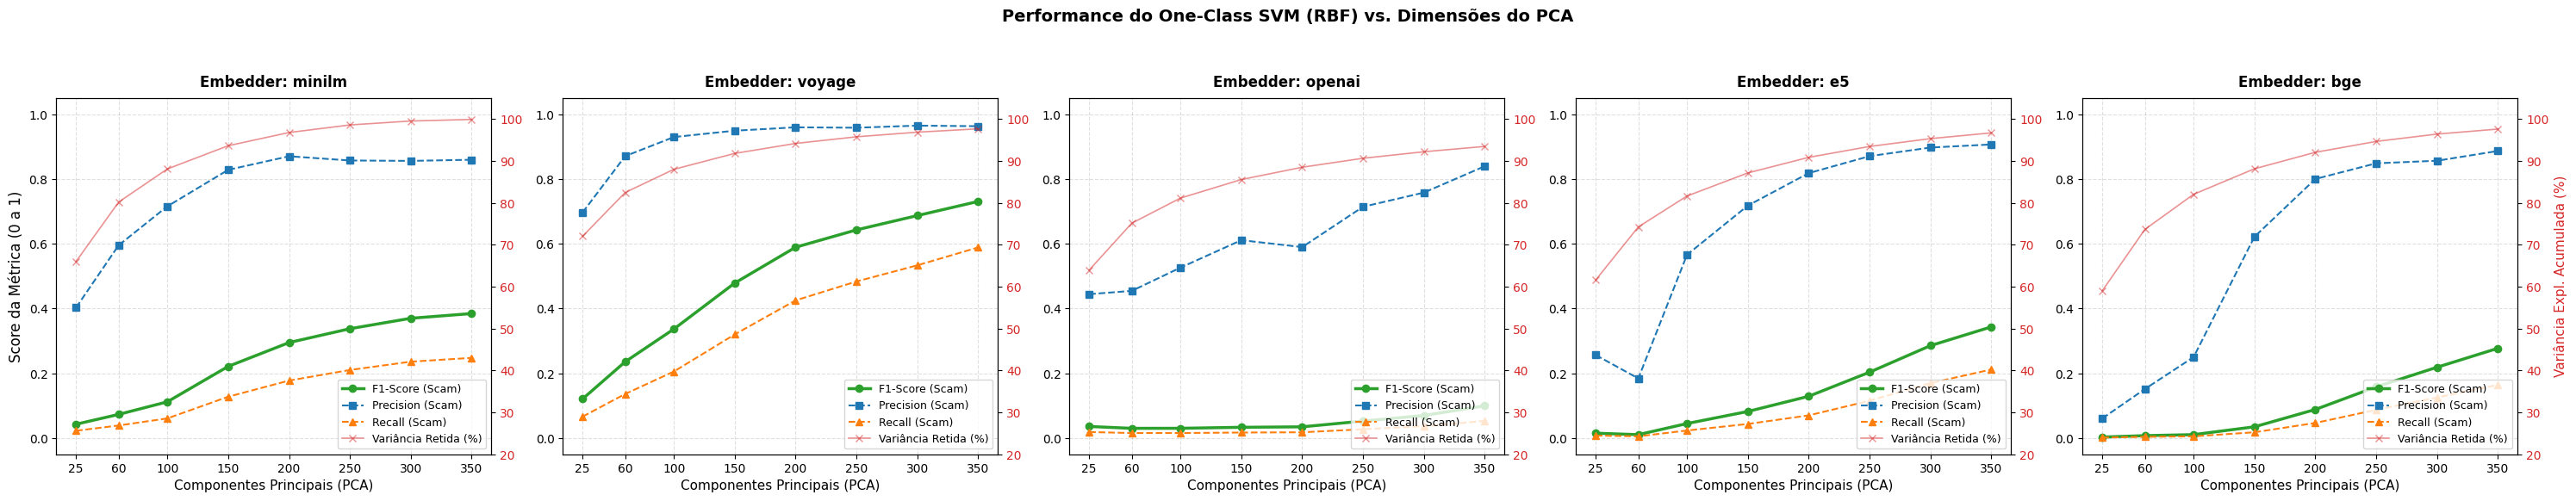

{'minilm':    Dimensões  Variância %  Precision    Recall  F1-Score
 0         25    65.980080   0.402778  0.022586  0.042773
 1         60    80.168114   0.595238  0.038941  0.073099
 2        100    88.077240   0.715596  0.060748  0.111989
 3        150    93.621696   0.828283  0.127726  0.221323
 4        200    96.777328   0.870229  0.177570  0.294955
 5        250    98.581177   0.857143  0.210280  0.337711
 6        300    99.519394   0.855932  0.235981  0.369963
 7        350    99.895615   0.859459  0.247664  0.384522,
 'voyage':    Dimensões  Variância %  Precision    Recall  F1-Score
 0         25    72.017075   0.696721  0.066199  0.120910
 1         60    82.458244   0.870647  0.136293  0.235690
 2        100    87.992790   0.929577  0.205607  0.336735
 3        150    91.786537   0.949192  0.320093  0.478742
 4        200    94.168007   0.959578  0.425234  0.589315
 5        250    95.754120   0.958333  0.483645  0.642857
 6        300    96.854309   0.964789  0.533489  0.

In [98]:
comparar_pipelines_ocsvm(EMBEDDERS.keys(), dimensoes=dimensions_test)

## 5. ESTUDO COM ISOLATION FOREST

In [ ]:
from sklearn.ensemble import IsolationForest

def _processar_metricas_iforest(embedder, dimensoes):
    """Função interna para calcular o pipeline do PCA + Isolation Forest para um único embedder."""
    print(f"\n Carregando e processando dados (Isolation Forest) para: {embedder}...")
    df = pd.read_parquet(os.path.join(DATA_DIR, f'{embedder}_chunks.parquet'))
    
    X = np.array(df['text_embedded'].tolist(), dtype=np.float32)
    y = np.array(df['label'].tolist())
    
    # Separação de treino e teste (80/20)
    X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Filtra treino para conter APENAS dados benignos (label = 0)
    X_train_benign = X_train_raw[y_train_raw == 0]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_benign)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # Conversão das labels de teste para o padrão do sklearn (1: normal, -1: anomalia)
    y_test_converted = np.where(y_test == 0, 1, -1)
    
    historico = {
        'variance': [], 'precision': [], 'recall': [], 'f1': []
    }
    
    for dim in dimensoes:
        # Redução via PCA
        pca = PCA(n_components=dim, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)
        
        variance_retained = np.sum(pca.explained_variance_ratio_) * 100
        historico['variance'].append(variance_retained)
        
        # Instanciação da Isolation Forest
        # contamination=0.05 assume que, mesmo na base benigna, toleramos até 5% de falsos positivos no limiar
        iforest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
        iforest.fit(X_train_pca)
        
        # Predição (retorna 1 para inliers e -1 para outliers)
        y_pred = iforest.predict(X_test_pca)
        
        # Calcula as métricas focando na classe de Scams (pos_label=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test_converted, y_pred, pos_label=-1, average='binary', zero_division=0
        )
        
        historico['precision'].append(precision)
        historico['recall'].append(recall)
        historico['f1'].append(f1)
        
    return historico


def comparar_pipelines_iforest(embedders_list, dimensoes=[25, 60, 100, 150, 200]):
    """
    Recebe uma lista de embedders e gera gráficos comparativos 
    lado a lado contendo as métricas da Isolation Forest e do PCA.
    """
    n_embedders = len(embedders_list)
    
    # Define a grade de subplots lado a lado dinamicamente
    fig, axes = plt.subplots(1, n_embedders, figsize=(6 * n_embedders, 5.5), squeeze=False)
    
    dfs_resultado = {}
    
    for idx, embedder in enumerate(embedders_list):
        ax1 = axes[0, idx]
        
        # Roda o processamento matemático para a Isolation Forest
        dados = _processar_metricas_iforest(embedder, dimensoes)
        
        # 1. Plot das métricas do classificador (Eixo Esquerdo)
        ax1.plot(dimensoes, dados['f1'], marker='o', linewidth=2.5, color='#4A90E2', label='F1-Score (Scam)')
        ax1.plot(dimensoes, dados['precision'], marker='s', linewidth=1.5, linestyle='--', color='#50E3C2', label='Precision (Scam)')
        ax1.plot(dimensoes, dados['recall'], marker='^', linewidth=1.5, linestyle='--', color='#B8E986', label='Recall (Scam)')
        
        ax1.set_xlabel('Componentes Principais (PCA)', fontsize=11)
        if idx == 0:
            ax1.set_ylabel('Score da Métrica (0 a 1)', fontsize=12)
        ax1.set_xticks(dimensoes)
        ax1.set_ylim(-0.05, 1.05)
        ax1.grid(True, linestyle='--', alpha=0.4)
        ax1.set_title(f'Embedder: {embedder}', fontsize=12, fontweight='bold', pad=10)
        
        # 2. Plot da Variância Acumulada (Eixo Direito Gêmeo)
        ax2 = ax1.twinx()
        ax2.plot(dimensoes, dados['variance'], marker='x', linewidth=1.2, color='#d62728', alpha=0.5, label='Variância Retida (%)')
        
        if idx == n_embedders - 1:
            ax2.set_ylabel('Variância Expl. Acumulada (%)', color='#d62728', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='#d62728')
        ax2.set_ylim(min(20, ax2.get_ylim()[0]), 105)
        
        # Une as legendas no canto do subplot
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
        
        # Estrutura em formato DataFrame para consulta posterior
        dfs_resultado[embedder] = pd.DataFrame({
            'Dimensões': dimensoes,
            'Variância %': dados['variance'],
            'Precision': dados['precision'],
            'Recall': dados['recall'],
            'F1-Score': dados['f1']
        })
        
    plt.suptitle('Performance da Isolation Forest vs. Dimensões do PCA', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    return dfs_resultado


 Carregando e processando dados (Isolation Forest) para: minilm...

 Carregando e processando dados (Isolation Forest) para: voyage...

 Carregando e processando dados (Isolation Forest) para: openai...

 Carregando e processando dados (Isolation Forest) para: e5...

 Carregando e processando dados (Isolation Forest) para: bge...


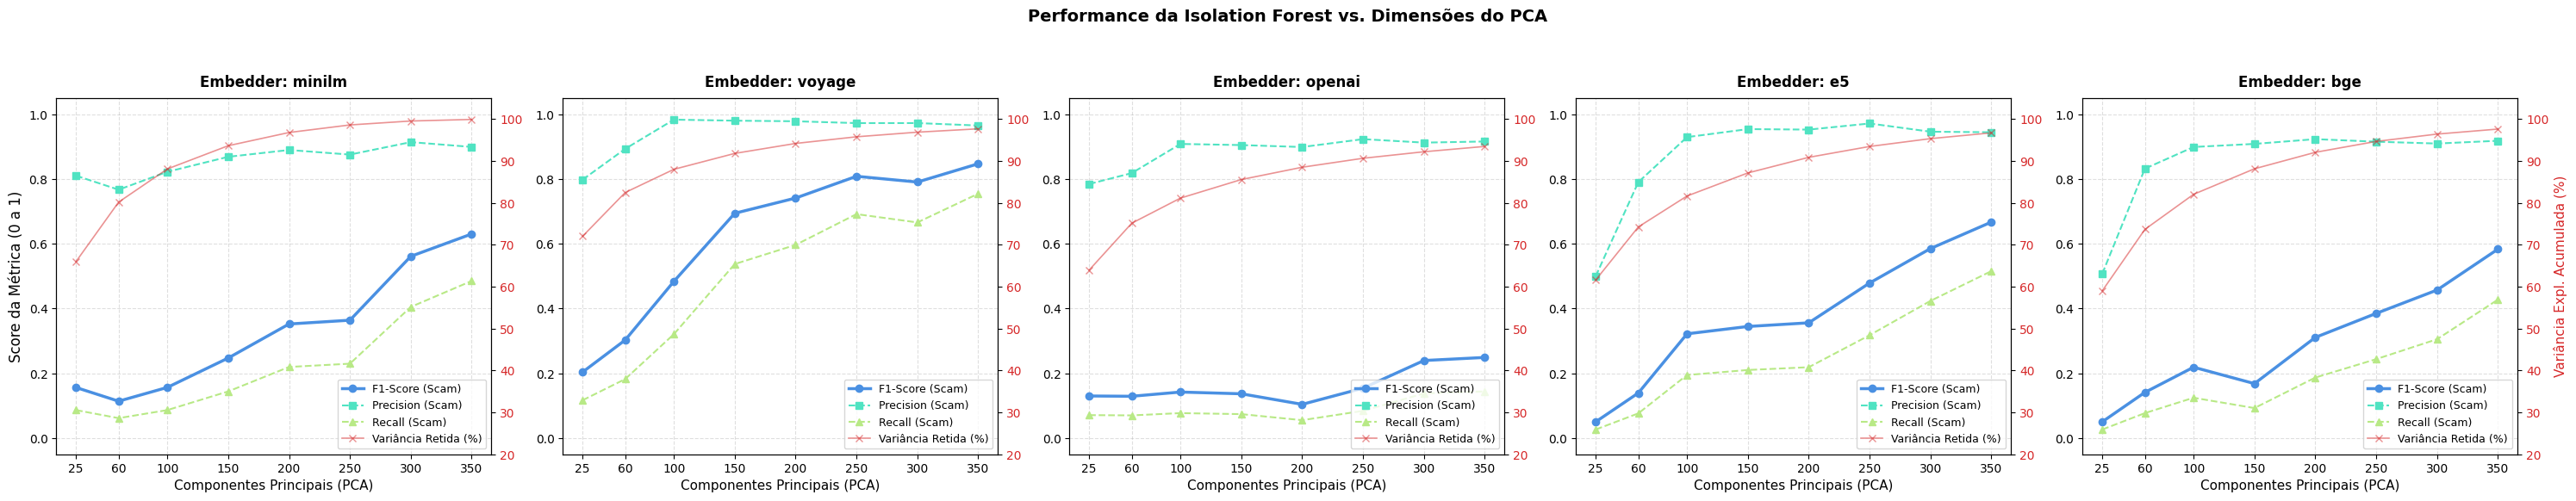

In [100]:
dict_dfs_iforest = comparar_pipelines_iforest(EMBEDDERS.keys(), dimensoes=dimensions_test)

## 6. Avaliar o tamanho do Dataset para aprendizado

Agora, podemos olhar ainda para como a quantidade de dados influencia o aprendizado do modelo

In [10]:
# --- AVALIAÇÃO DE APRENDIZADO POR FRAÇÕES DO DATASET DE TREINO ---
# Agora usando os modelos de detecção de anomalias: One-Class SVM e Isolation Forest
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import math


def plot_learning_curve_anomaly(embedding, model_type='ocsvm', train_sizes=None, n_repeats=3, random_state=42, path_data='all_data'):
    """
    Avalia o desempenho de um detector de anomalias (One-Class SVM ou IsolationForest)
    treinando com diferentes frações do conjunto de treino (apenas exemplos benignos).

    O modelo é treinado para cada porcentagem de dados e avaliado em:
    1) conjunto de teste interno (split do dataset de treino)
    2) dataset de validação externo em ../datasets/dataset_validation/processed/{path_data}/{embedding}_chunks.parquet

    Params:
    - embedding: nome do embedder (ex: 'voyage') que indica o parquet a carregar
    - model_type: 'ocsvm' ou 'iforest'
    - train_sizes: lista de frações do conjunto de treino a usar (0-1)
    - n_repeats: quantas repetições por fração (amostragem aleatória)
    - path_data: pasta de dados (ex: 'all_data' ou 'suspect_turns') para montar o caminho dos parquet

    Retorna um DataFrame com médias e desvios das métricas por fração e plota também
    uma curva de FP/FN médios na validação e uma matriz de confusão (para a maior fração).
    """
    if train_sizes is None:
        train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

    train_parquet = os.path.join('..', 'datasets', 'dataset_train', 'processed', path_data, f'{embedding}_chunks.parquet')
    df = pd.read_parquet(train_parquet)
    X = np.array(df['text_embedded'].tolist(), dtype=np.float32)
    y = np.array(df['label'].tolist())

    validation_parquet = os.path.join('..', 'datasets', 'dataset_validation', 'processed', path_data, f'{embedding}_chunks.parquet')
    if os.path.exists(validation_parquet):
        df_val = pd.read_parquet(validation_parquet)
        if df_val.empty:
            print(f'Parquet de validação vazio para {embedding} em {path_data}. Usando conjunto de validação interno.')
            df_val = None
        else:
            X_val = np.array(df_val['text_embedded'].tolist(), dtype=np.float32)
            y_val = np.array(df_val['label'].tolist())
    else:
        print(f'Parquet de validação não encontrado: {validation_parquet}. Usando conjunto de validação interno.')
        df_val = None

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )
    X_train_benign = X_train_full[y_train_full == 0]

    scaler = StandardScaler().fit(X_train_benign)
    X_train_benign_scaled = scaler.transform(X_train_benign)
    X_test_scaled = scaler.transform(X_test)

    if df_val is not None:
        X_val_scaled = scaler.transform(X_val)
        y_val_conv = np.where(y_val == 0, 1, -1)
        validation_label = 'validation_external'
    else:
        X_train_full_inner, X_val_internal, y_train_full_inner, y_val_internal = train_test_split(
            X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=random_state
        )
        X_val_scaled = scaler.transform(X_val_internal)
        y_val_conv = np.where(y_val_internal == 0, 1, -1)
        validation_label = 'validation_internal'

    y_test_conv = np.where(y_test == 0, 1, -1)

    results = []
    n_benign = X_train_benign_scaled.shape[0]

    # listas para armazenar médias de FP / FN na validação
    val_fp_means = []
    val_fn_means = []
    cm_avgs = []

    for frac in train_sizes:
        test_precs = []
        test_recs = []
        test_f1s = []
        val_precs = []
        val_recs = []
        val_f1s = []

        # acumulador de matrizes de confusão para esta fracção
        val_cm_sum = np.zeros((2, 2), dtype=float)  # labels order: [1 (normal), -1 (anomaly)]

        n_samples = max(1, int(np.floor(n_benign * frac)))

        for rep in range(n_repeats):
            rng = np.random.RandomState(random_state + rep)
            idxs = rng.choice(n_benign, size=n_samples, replace=False)
            X_sub = X_train_benign_scaled[idxs]
            
            if model_type == 'ocsvm':
                model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
            elif model_type == 'iforest':
                model = IsolationForest(n_estimators=100, contamination=0.05, random_state=random_state + rep, n_jobs=-1)
            else:
                raise ValueError('model_type must be "ocsvm" or "iforest"')

            model.fit(X_sub)
            y_pred_test = model.predict(X_test_scaled)
            y_pred_val = model.predict(X_val_scaled)

            precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(
                y_test_conv, y_pred_test, pos_label=-1, average='binary', zero_division=0
            )
            precision_val, recall_val, f1_val, _ = precision_recall_fscore_support(
                y_val_conv, y_pred_val, pos_label=-1, average='binary', zero_division=0
            )

            # Confusion matrix para esta repetição (labels fixos para manter ordem)
            cm = confusion_matrix(y_val_conv, y_pred_val, labels=[1, -1])
            val_cm_sum += cm

            test_precs.append(precision_test)
            test_recs.append(recall_test)
            test_f1s.append(f1_test)
            val_precs.append(precision_val)
            val_recs.append(recall_val)
            val_f1s.append(f1_val)

        # média da matriz de confusão sobre repetições
        cm_avg = val_cm_sum / float(n_repeats)
        cm_avgs.append(cm_avg)
        # FP = true normal (1) predicted anomaly (-1) => cm[0,1]
        # FN = true anomaly (-1) predicted normal (1) => cm[1,0]
        val_fp_means.append(cm_avg[0, 1])
        val_fn_means.append(cm_avg[1, 0])

        results.append({
            'frac': frac,
            'precision_test_mean': np.mean(test_precs),
            'precision_test_std': np.std(test_precs),
            'recall_test_mean': np.mean(test_recs),
            'recall_test_std': np.std(test_recs),
            'f1_test_mean': np.mean(test_f1s),
            'f1_test_std': np.std(test_f1s),
            'precision_val_mean': np.mean(val_precs),
            'precision_val_std': np.std(val_precs),
            'recall_val_mean': np.mean(val_recs),
            'recall_val_std': np.std(val_recs),
            'f1_val_mean': np.mean(val_f1s),
            'f1_val_std': np.std(val_f1s),
            'validation_source': validation_label,
            'train_size': n_samples
        })

    results_df = pd.DataFrame(results)

    plt.figure(figsize=(12, 6))
    plt.plot(results_df['frac'] * 100, results_df['f1_test_mean'], marker='o', label='F1-score (test)')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['f1_test_mean'] - results_df['f1_test_std'],
                     results_df['f1_test_mean'] + results_df['f1_test_std'],
                     alpha=0.18)
    plt.plot(results_df['frac'] * 100, results_df['precision_test_mean'], marker='s', label='Precision (test)')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['precision_test_mean'] - results_df['precision_test_std'],
                     results_df['precision_test_mean'] + results_df['precision_test_std'],
                     alpha=0.12)
    plt.plot(results_df['frac'] * 100, results_df['recall_test_mean'], marker='^', label='Recall (test)')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['recall_test_mean'] - results_df['recall_test_std'],
                     results_df['recall_test_mean'] + results_df['recall_test_std'],
                     alpha=0.12)

    plt.title(f'Learning Curve Interna — {model_type.upper()} | {embedding} ({path_data})')
    plt.xlabel('Percentual de dados benignos usados para treino (%)')
    plt.ylabel('Métrica no conjunto de teste interno')
    plt.xticks(results_df['frac'] * 100)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(results_df['frac'] * 100, results_df['f1_val_mean'], marker='o', label=f'F1-score ({validation_label})')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['f1_val_mean'] - results_df['f1_val_std'],
                     results_df['f1_val_mean'] + results_df['f1_val_std'],
                     alpha=0.18)
    plt.plot(results_df['frac'] * 100, results_df['precision_val_mean'], marker='s', label=f'Precision ({validation_label})')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['precision_val_mean'] - results_df['precision_val_std'],
                     results_df['precision_val_mean'] + results_df['precision_val_std'],
                     alpha=0.12)
    plt.plot(results_df['frac'] * 100, results_df['recall_val_mean'], marker='^', label=f'Recall ({validation_label})')
    plt.fill_between(results_df['frac'] * 100,
                     results_df['recall_val_mean'] - results_df['recall_val_std'],
                     results_df['recall_val_mean'] + results_df['recall_val_std'],
                     alpha=0.12)

    plt.title(f'Learning Curve de Validação — {model_type.upper()} | {embedding} ({path_data})')
    plt.xlabel('Percentual de dados benignos usados para treino (%)')
    plt.ylabel('Métrica no conjunto de validação')
    plt.xticks(results_df['frac'] * 100)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

    # Mostrar matriz de confusão média para a maior fração (último elemento)
    if len(cm_avgs) > 0:
        last_cm = cm_avgs[-1]
        disp = ConfusionMatrixDisplay(confusion_matrix=last_cm, display_labels=[ 'Normal (0)', 'Anomaly (1)'])
        fig, ax = plt.subplots(figsize=(10, 5))
        disp.plot(ax=ax, cmap='Blues', colorbar=True)
        ax.set_title(f'Matriz de Confusão Média ({int(train_sizes[-1]*100)}% treino) — {validation_label}')
        plt.tight_layout()
        plt.show()

    return results_df



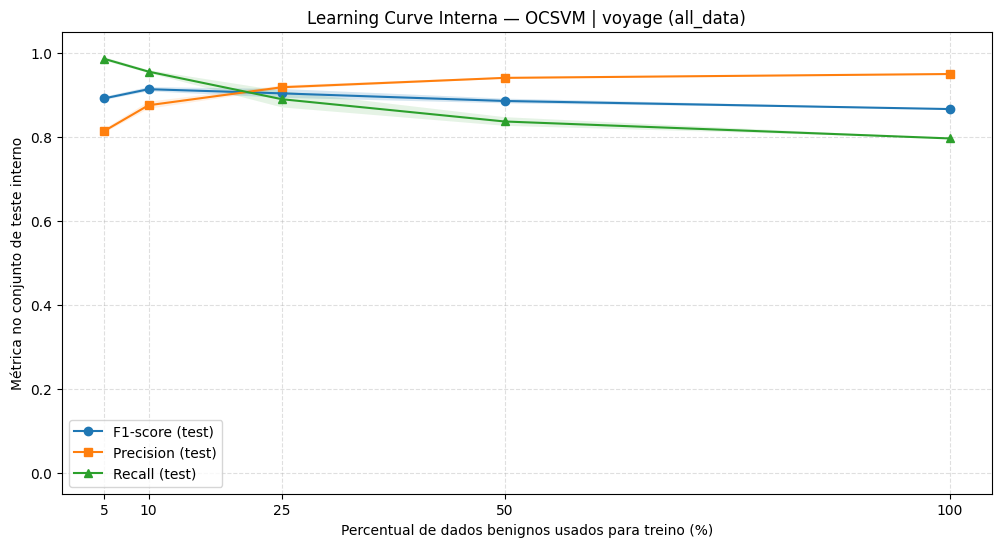

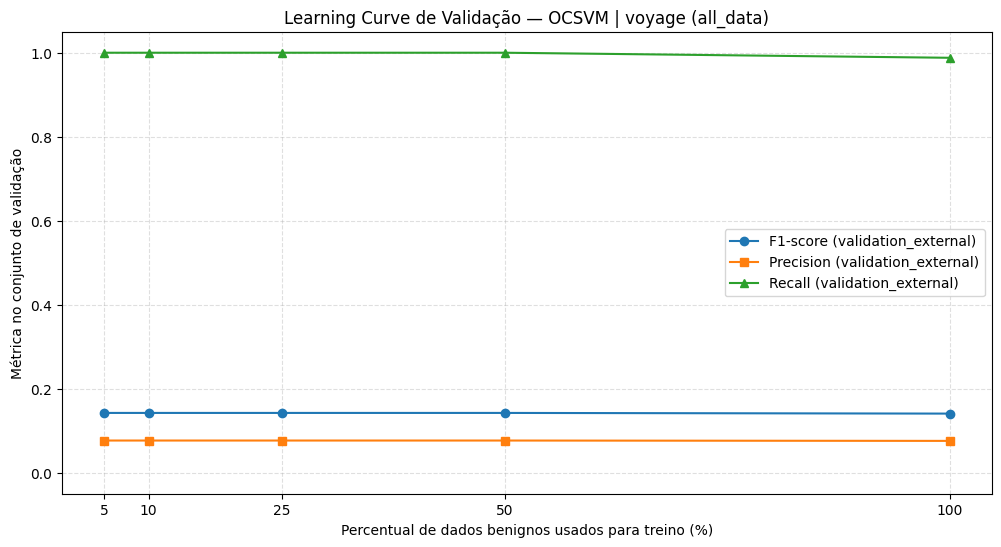

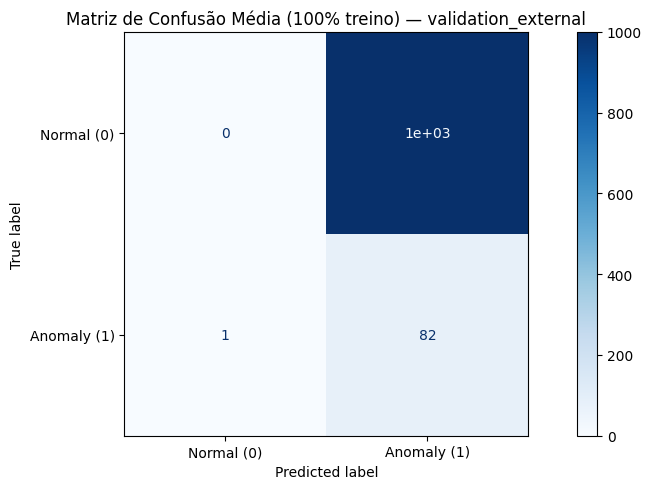

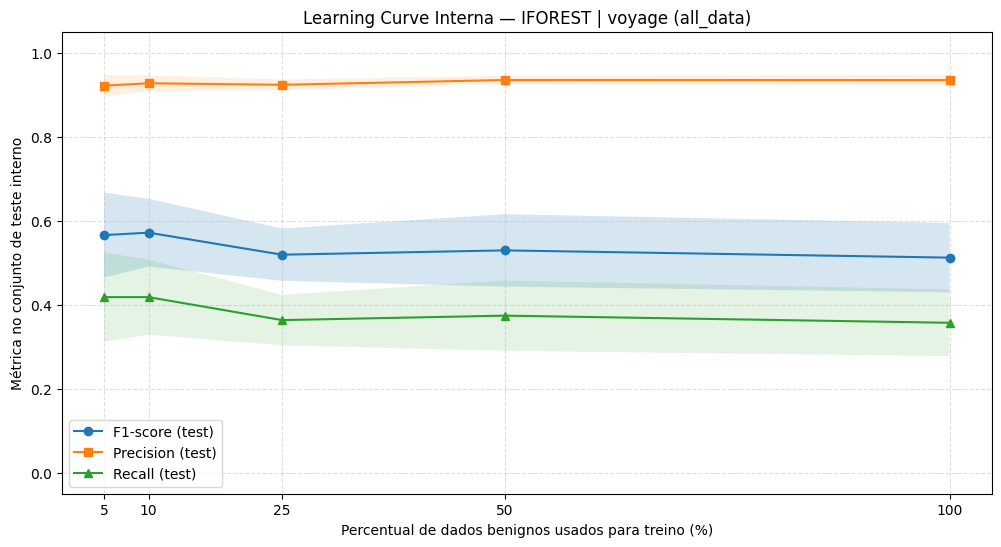

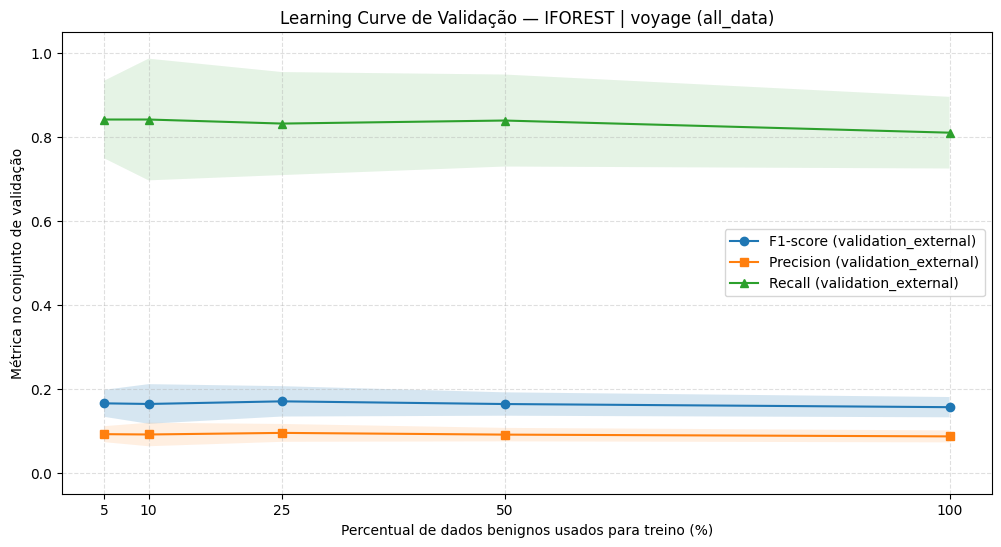

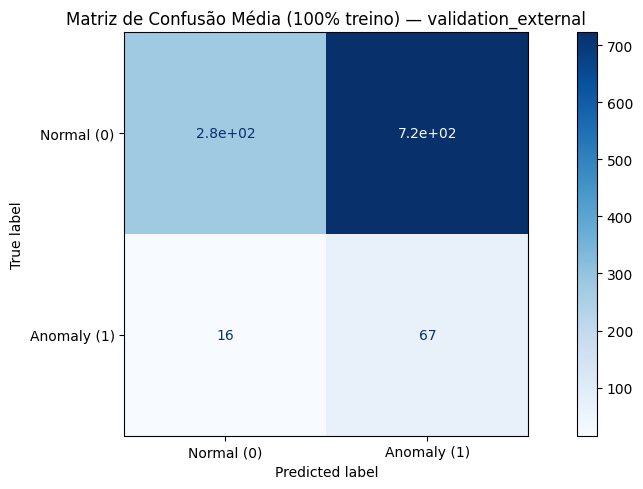

   frac  precision_test_mean  precision_test_std  recall_test_mean  \
0  0.05             0.813357            0.004371          0.985514   
1  0.10             0.874936            0.008433          0.954984   
2  0.25             0.917851            0.004274          0.889252   
3  0.50             0.940125            0.001671          0.836293   
4  1.00             0.949285            0.000432          0.795950   

   recall_test_std  f1_test_mean  f1_test_std  precision_val_mean  \
0         0.004197      0.891193     0.003809            0.076639   
1         0.003531      0.913187     0.005041            0.076639   
2         0.019464      0.903220     0.010527            0.076639   
3         0.010313      0.885137     0.005581            0.076639   
4         0.000000      0.865882     0.000180            0.075786   

   precision_val_std  recall_val_mean  recall_val_std  f1_val_mean  \
0                0.0         1.000000    0.000000e+00     0.142367   
1                0.0    

In [11]:
results_ocsvm_voyage = plot_learning_curve_anomaly('voyage', model_type='ocsvm', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
results_iforest_voyage = plot_learning_curve_anomaly('voyage', model_type='iforest', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
print(results_ocsvm_voyage)
print(results_iforest_voyage)

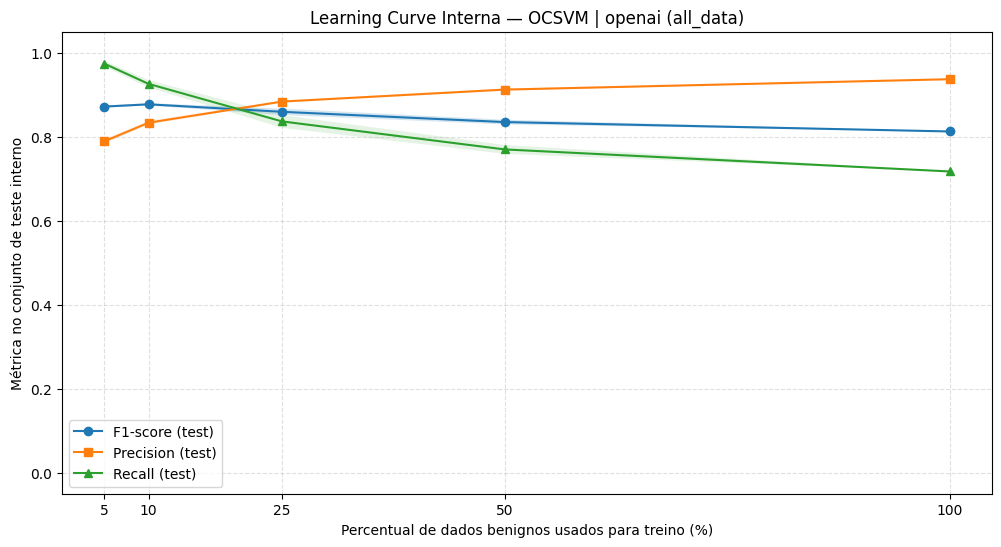

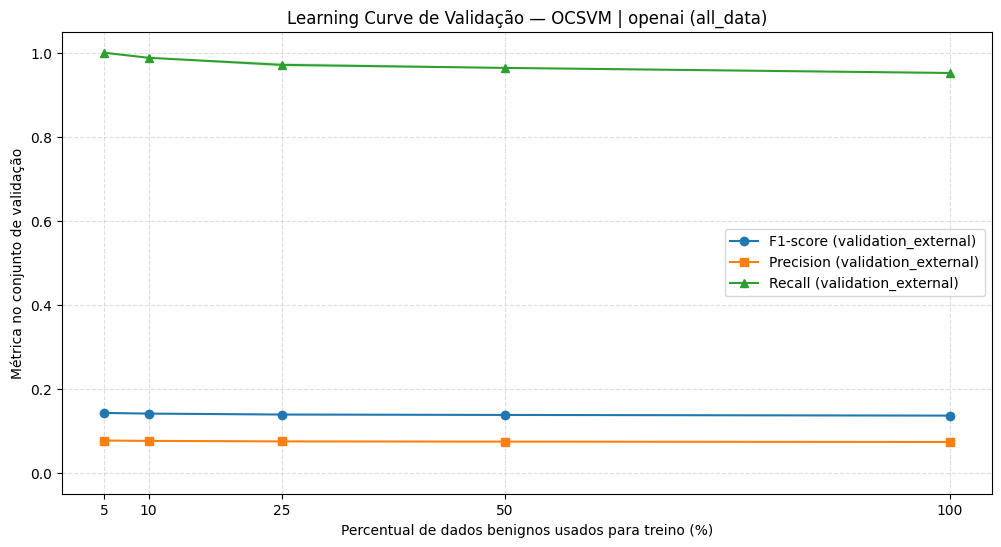

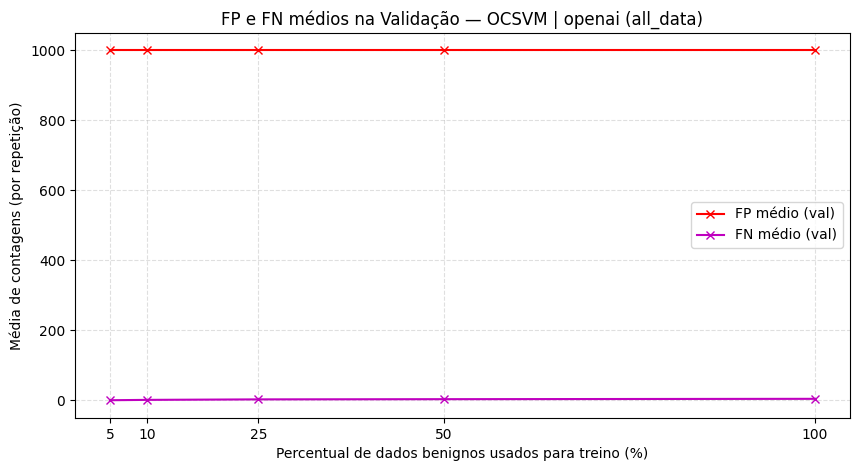

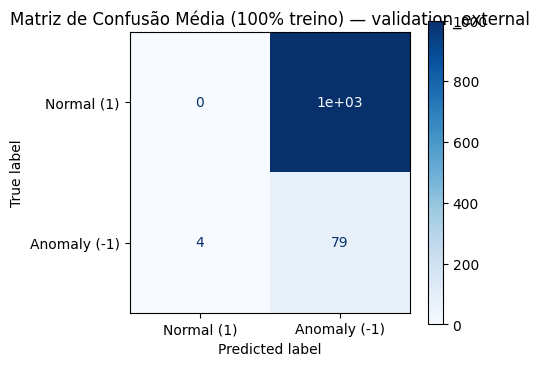

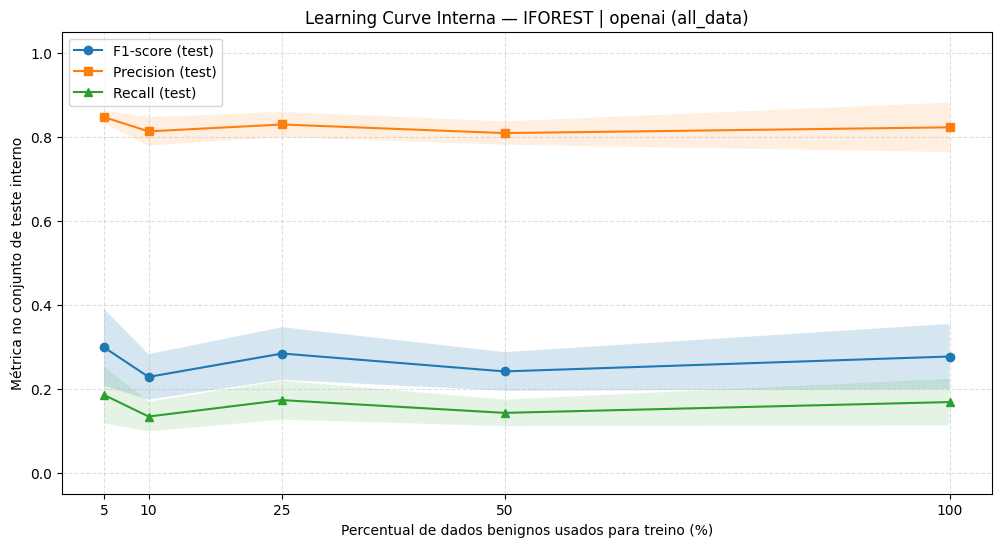

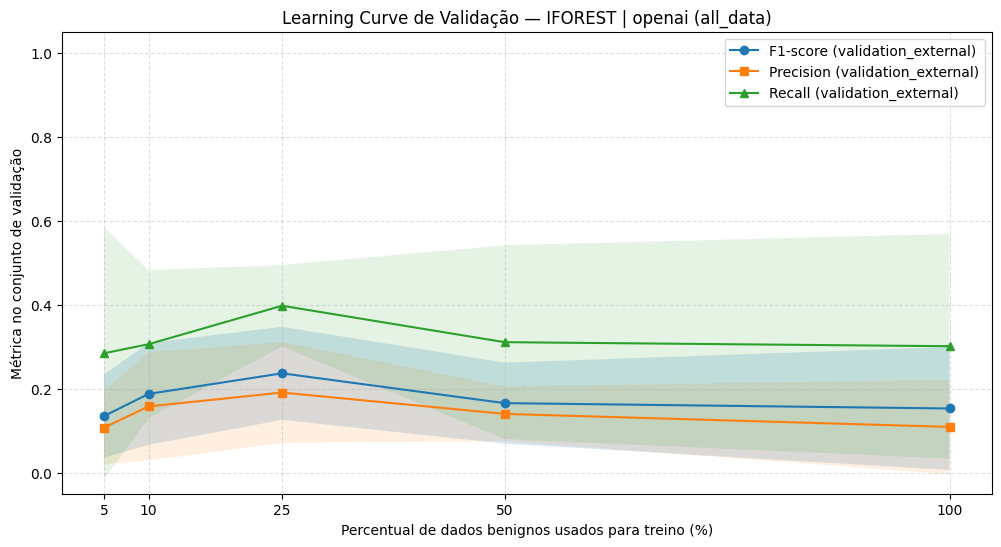

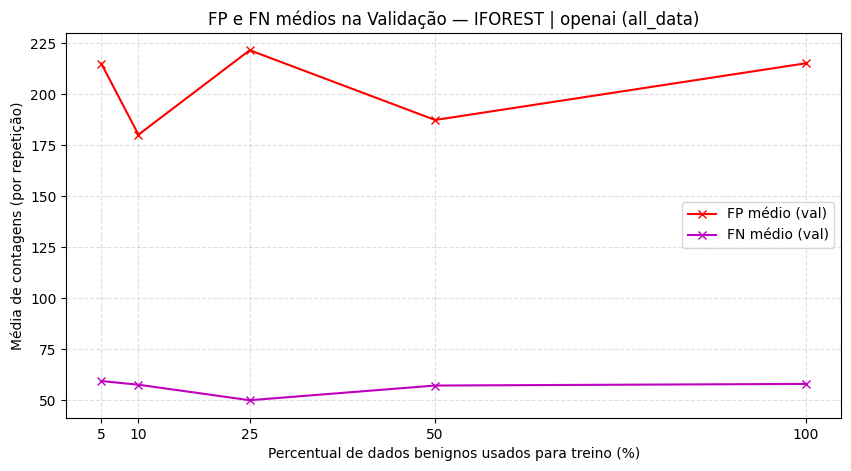

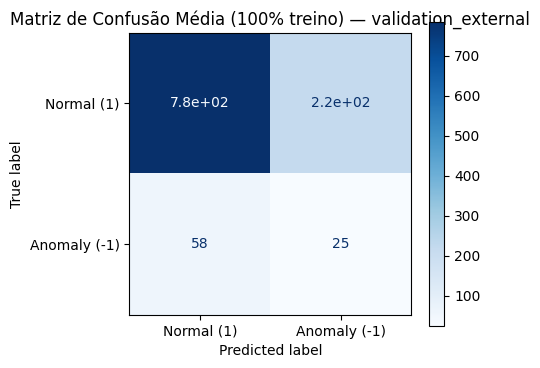

   frac  precision_test_mean  precision_test_std  recall_test_mean  \
0  0.05             0.788742            0.005357          0.974299   
1  0.10             0.833366            0.004613          0.925857   
2  0.25             0.883679            0.001892          0.836449   
3  0.50             0.912176            0.002596          0.769782   
4  1.00             0.936928            0.000000          0.717290   

   recall_test_std  f1_test_mean   f1_test_std  precision_val_mean  \
0         0.006736      0.871720  2.060425e-03            0.076639   
1         0.008913      0.877137  2.867583e-03            0.075786   
2         0.015126      0.859337  7.630894e-03            0.074588   
3         0.010583      0.834900  5.595635e-03            0.074074   
4         0.000000      0.812528  1.110223e-16            0.073216   

   precision_val_std  recall_val_mean  recall_val_std  f1_val_mean  \
0            0.00000         1.000000    0.000000e+00     0.142367   
1            0.000

In [4]:
results_ocsvm_voyage = plot_learning_curve_anomaly('openai', model_type='ocsvm', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
results_iforest_voyage = plot_learning_curve_anomaly('openai', model_type='iforest', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
print(results_ocsvm_voyage)
print(results_iforest_voyage)

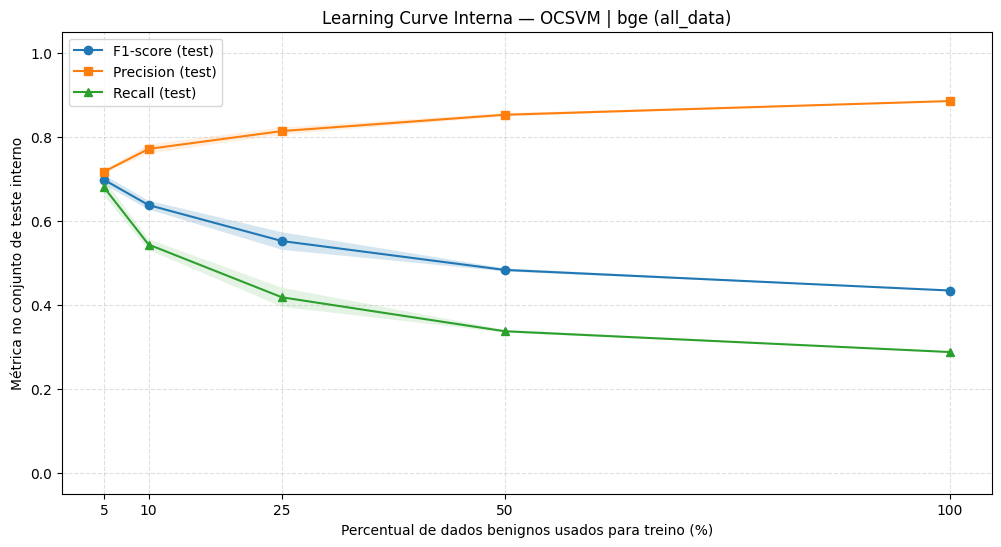

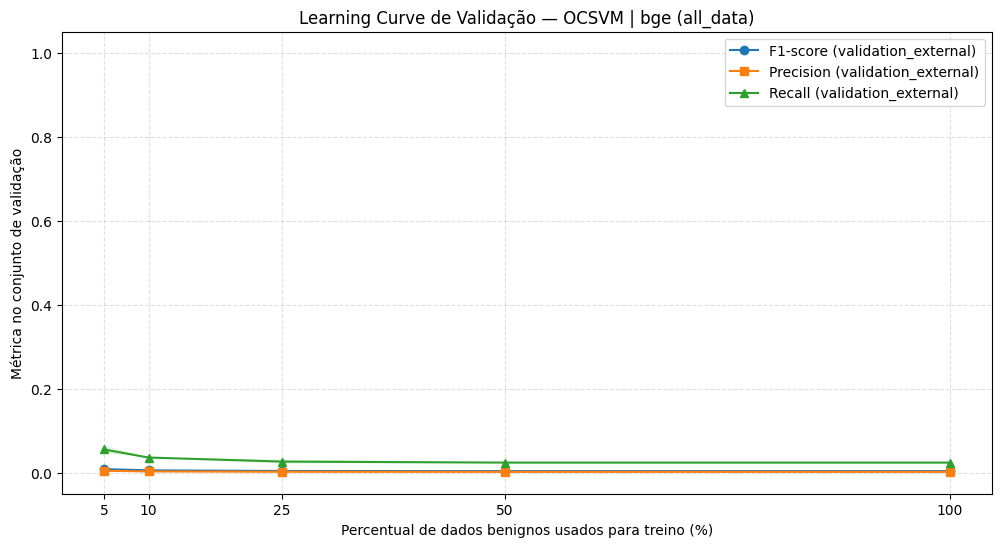

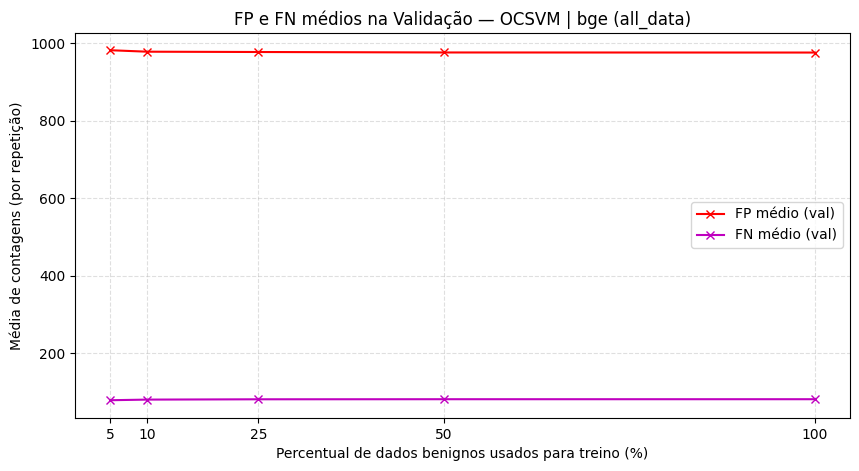

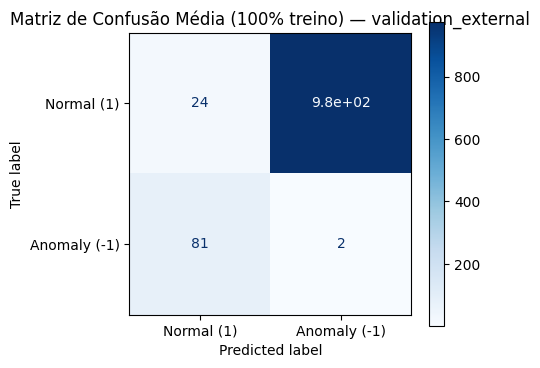

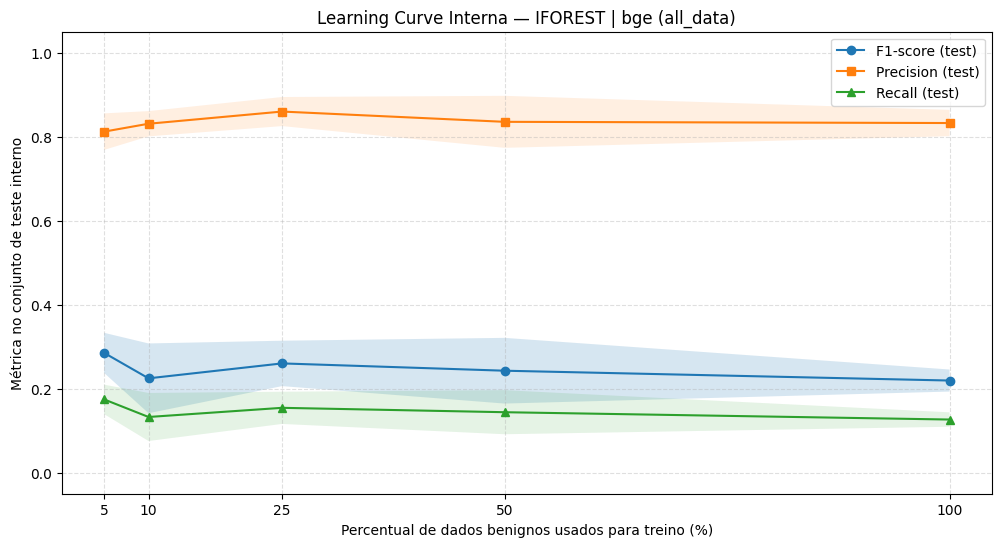

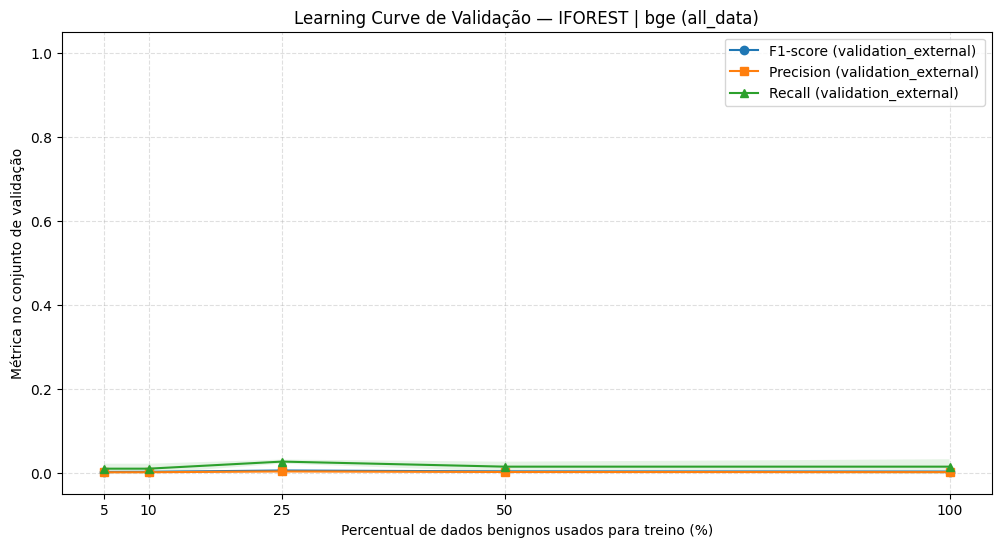

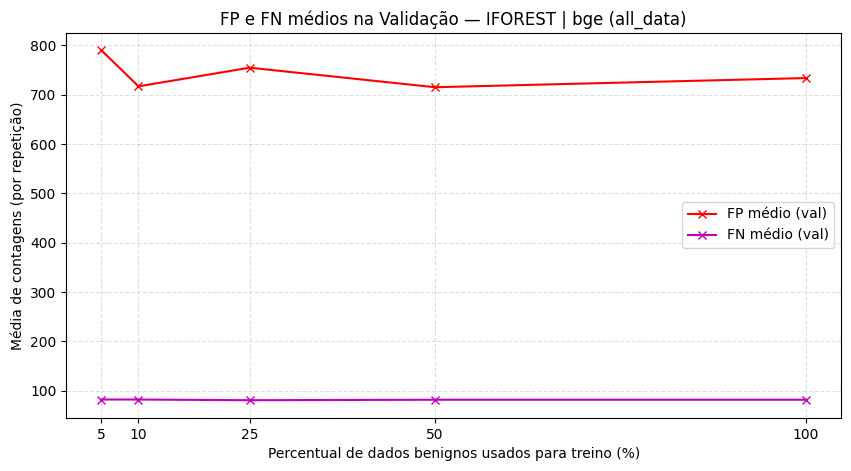

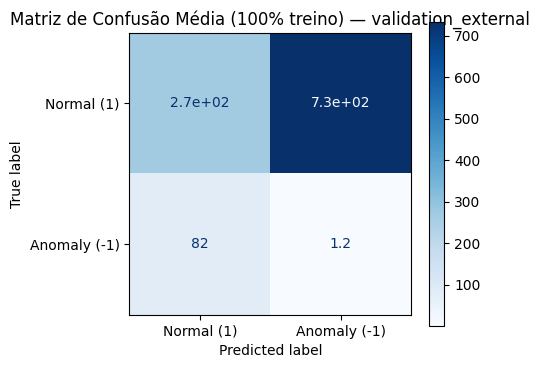

   frac  precision_test_mean  precision_test_std  recall_test_mean  \
0  0.05             0.716736            0.003160          0.679283   
1  0.10             0.770922            0.010953          0.543302   
2  0.25             0.813482            0.008408          0.417601   
3  0.50             0.852253            0.003933          0.336916   
4  1.00             0.884892            0.000000          0.287383   

   recall_test_std  f1_test_mean  f1_test_std  precision_val_mean  \
0         0.019513      0.697396     0.011646            0.004661   
1         0.012831      0.637308     0.010524            0.003057   
2         0.022778      0.551592     0.020837            0.002246   
3         0.003434      0.482912     0.003750            0.002045   
4         0.000000      0.433862     0.000000            0.002045   

   precision_val_std  recall_val_mean  recall_val_std  f1_val_mean  \
0       8.063427e-04         0.055422        0.009639     0.008600   
1       1.245664e-06    

In [5]:
results_ocsvm_voyage = plot_learning_curve_anomaly('bge', model_type='ocsvm', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
results_iforest_voyage = plot_learning_curve_anomaly('bge', model_type='iforest', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
print(results_ocsvm_voyage)
print(results_iforest_voyage)

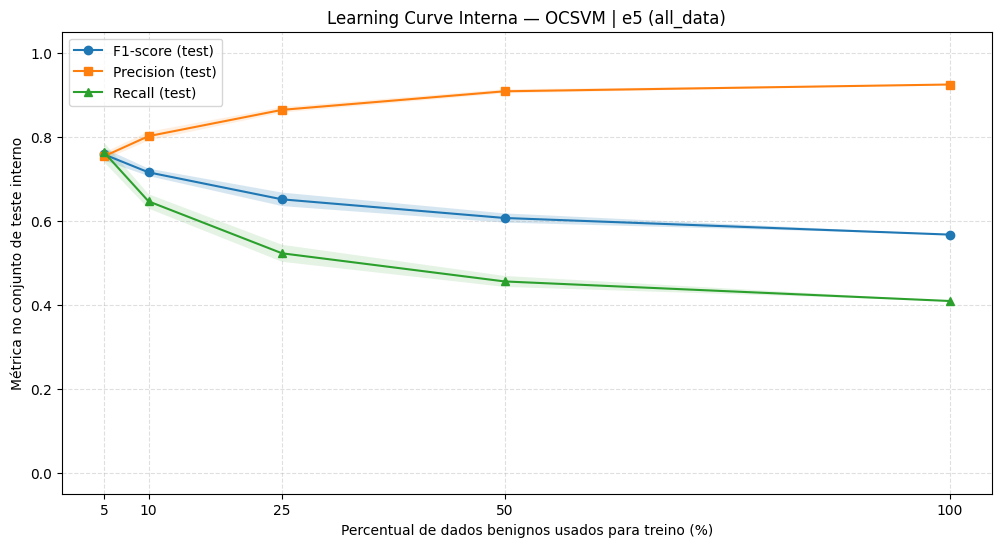

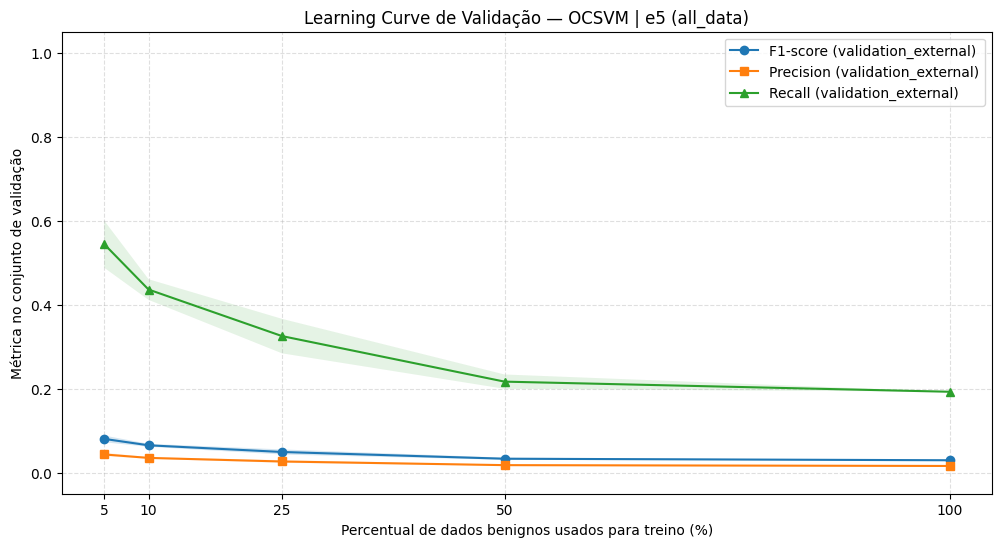

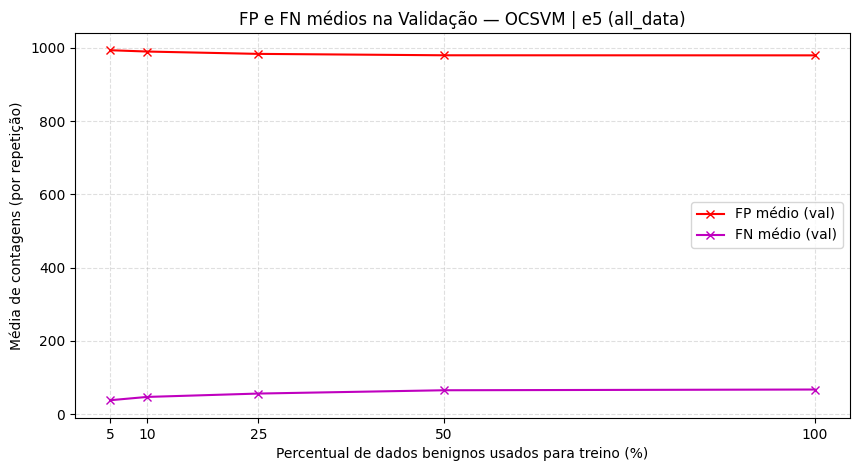

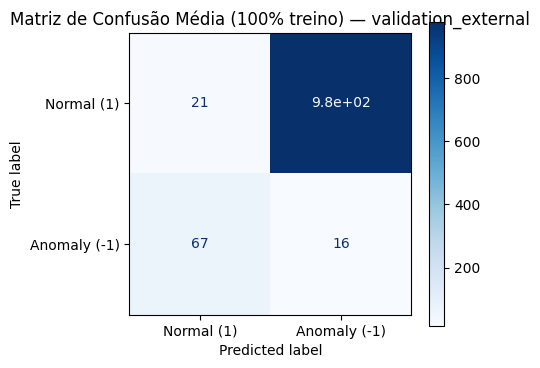

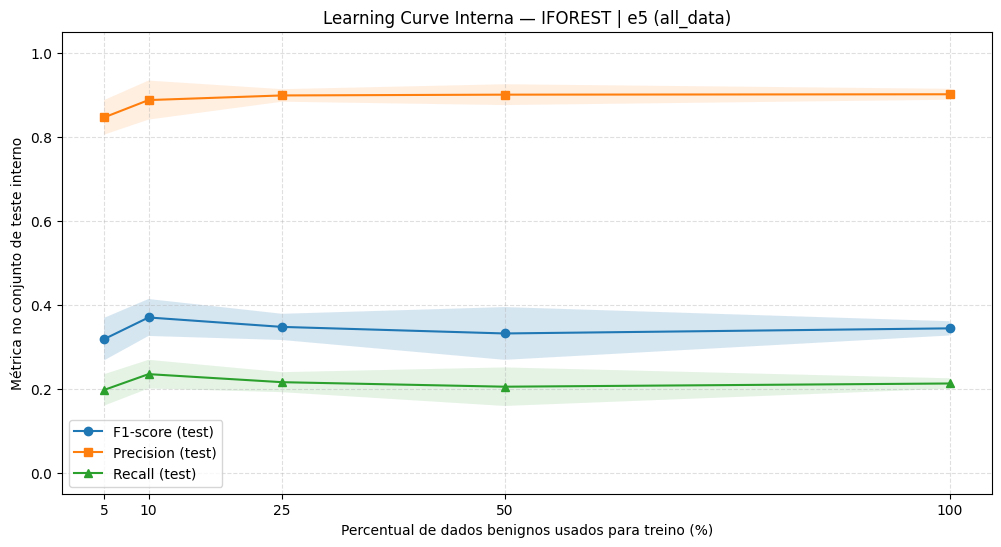

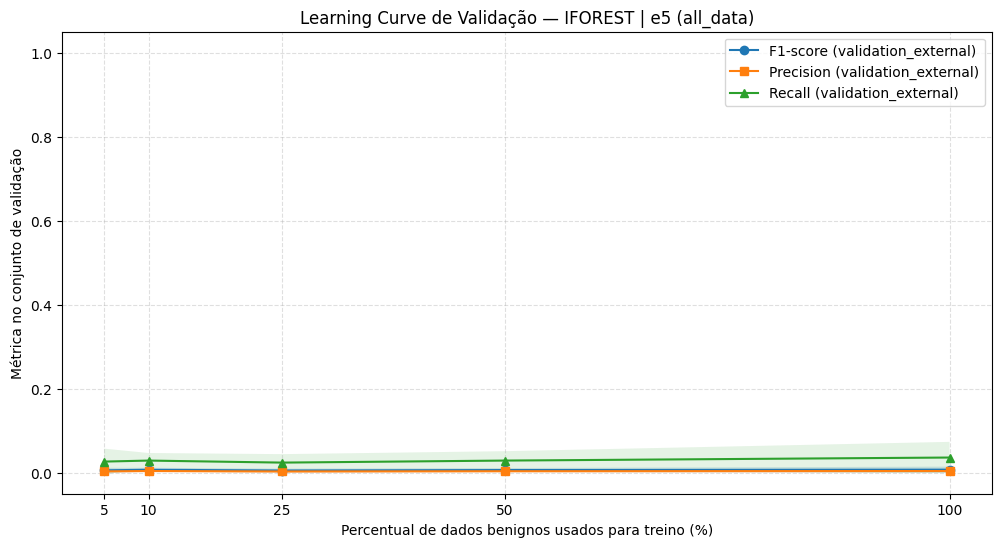

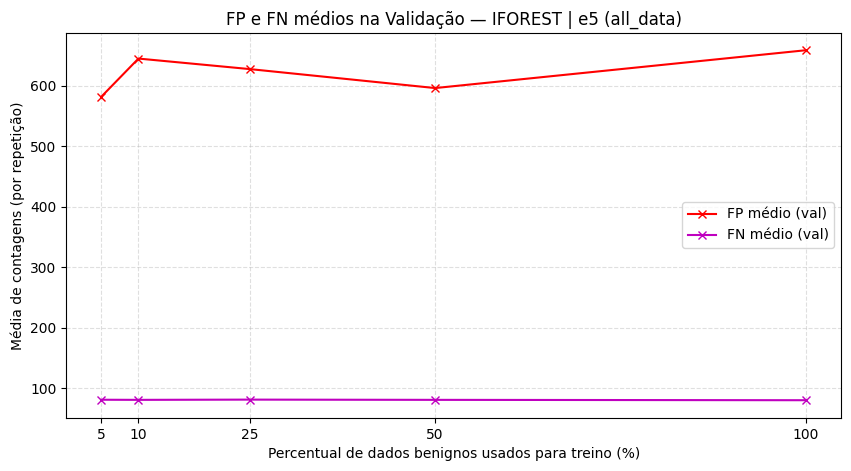

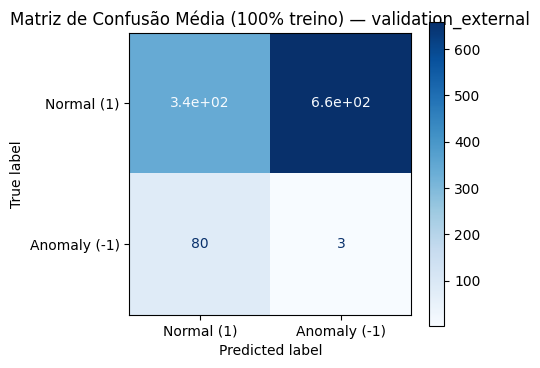

   frac  precision_test_mean  precision_test_std  recall_test_mean  \
0  0.05             0.753434            0.008759          0.762773   
1  0.10             0.801370            0.010465          0.646106   
2  0.25             0.863995            0.006474          0.522430   
3  0.50             0.908174            0.004900          0.455452   
4  1.00             0.924296            0.000000          0.408879   

   recall_test_std  f1_test_mean  f1_test_std  precision_val_mean  \
0         0.023196      0.757960     0.014639            0.043518   
1         0.017195      0.715190     0.008924            0.035291   
2         0.020282      0.650914     0.016079            0.026720   
3         0.013092      0.606525     0.011000            0.018048   
4         0.000000      0.566955     0.000000            0.016080   

   precision_val_std  recall_val_mean  recall_val_std  f1_val_mean  \
0           0.004294         0.544578        0.056202     0.080595   
1           0.001896    

In [6]:
results_ocsvm_voyage = plot_learning_curve_anomaly('e5', model_type='ocsvm', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
results_iforest_voyage = plot_learning_curve_anomaly('e5', model_type='iforest', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
print(results_ocsvm_voyage)
print(results_iforest_voyage)

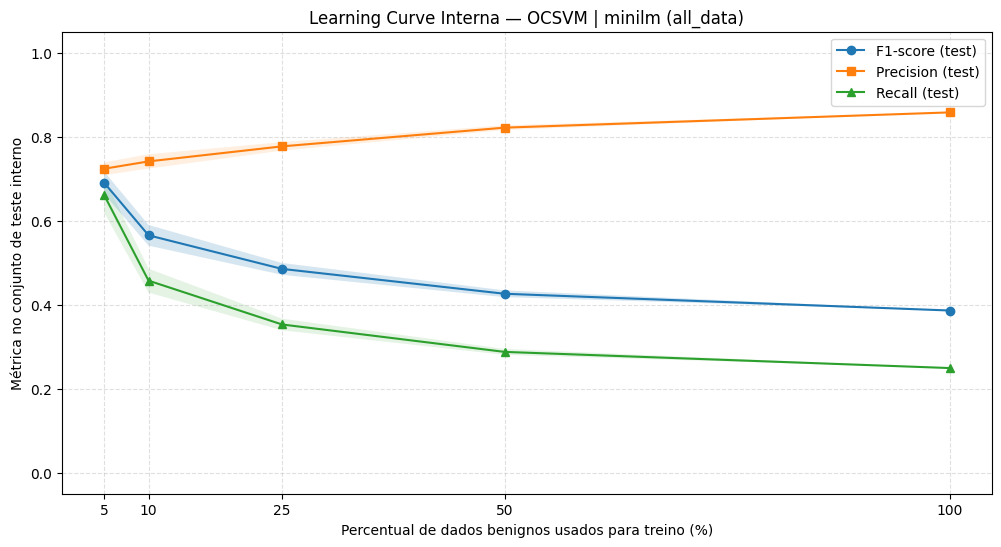

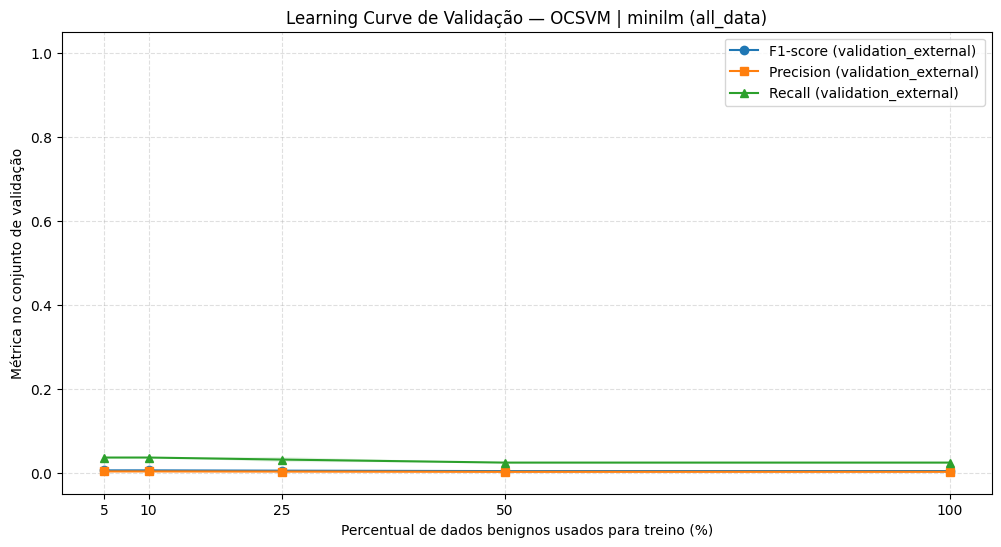

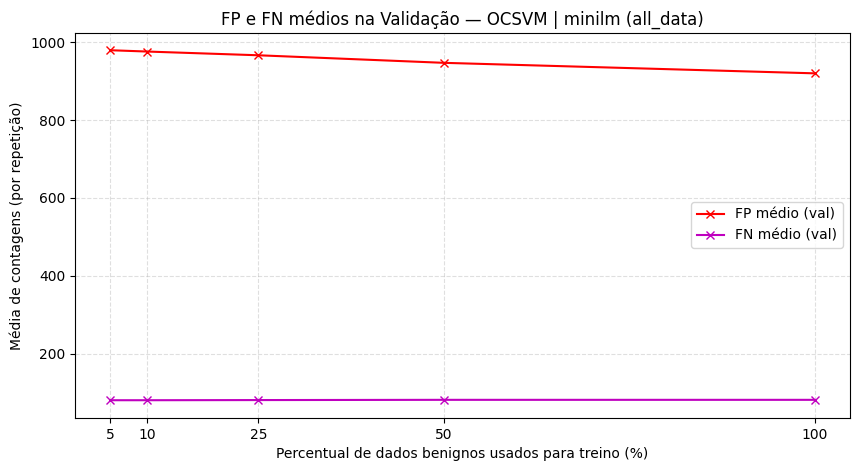

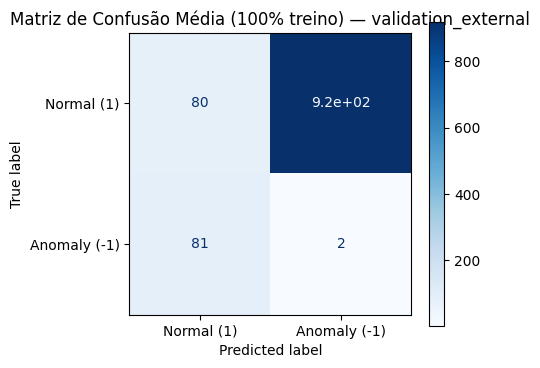

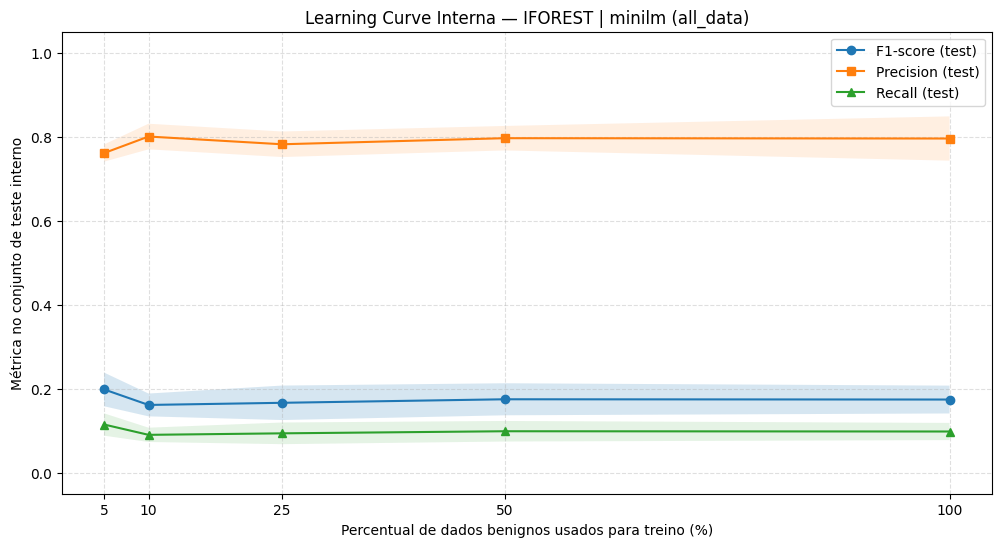

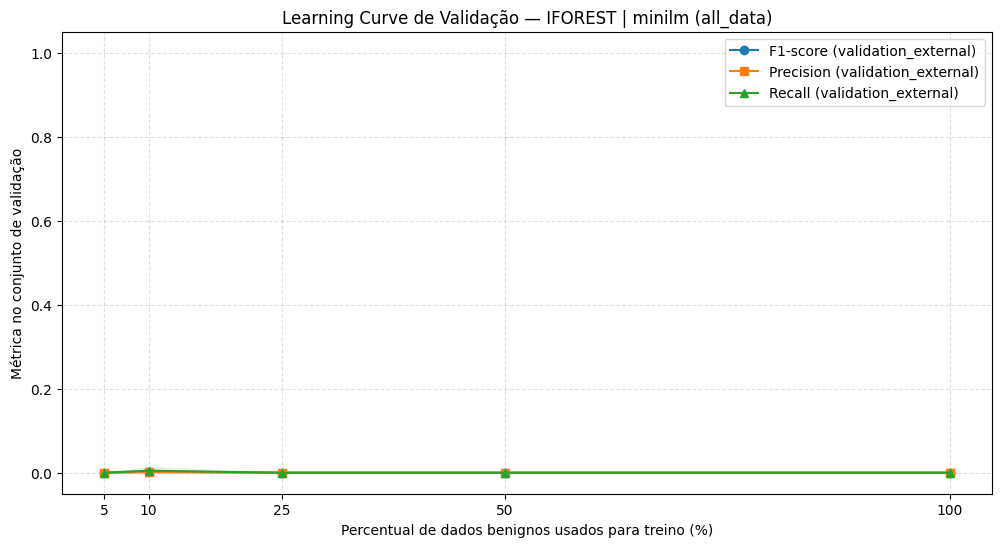

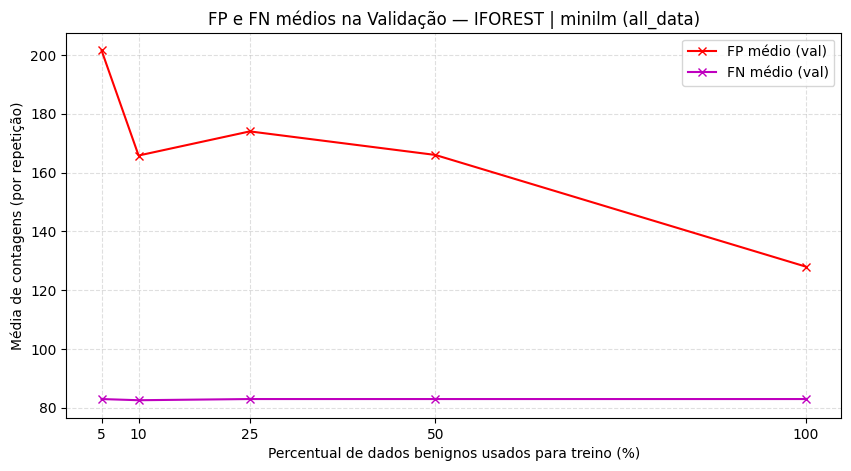

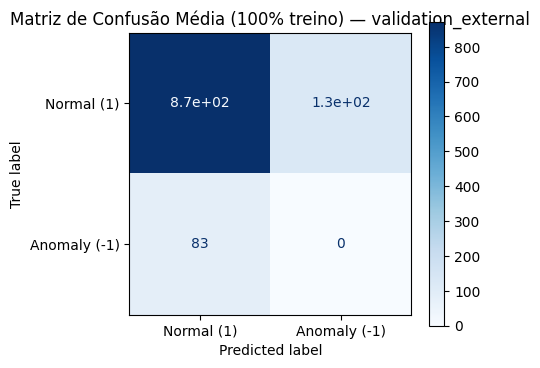

   frac  precision_test_mean  precision_test_std  recall_test_mean  \
0  0.05             0.723721            0.015151          0.661526   
1  0.10             0.741250            0.017067          0.457321   
2  0.25             0.777031            0.010187          0.352960   
3  0.50             0.821599            0.005596          0.287695   
4  1.00             0.857909            0.000000          0.249221   

   recall_test_std  f1_test_mean  f1_test_std  precision_val_mean  \
0     4.163456e-02      0.690706     0.026736            0.003054   
1     2.846421e-02      0.565273     0.024645            0.003064   
2     1.390051e-02      0.485294     0.014096            0.002680   
3     7.062794e-03      0.426121     0.008083            0.002108   
4     2.775558e-17      0.386240     0.000000            0.002169   

   precision_val_std  recall_val_mean  recall_val_std  f1_val_mean  \
0           0.000005         0.036145        0.000000     0.005632   
1           0.000005    

In [7]:
results_ocsvm_voyage = plot_learning_curve_anomaly('minilm', model_type='ocsvm', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
results_iforest_voyage = plot_learning_curve_anomaly('minilm', model_type='iforest', train_sizes=[0.05,0.1,0.25,0.5,1.0], n_repeats=5)
print(results_ocsvm_voyage)
print(results_iforest_voyage)